In [1]:
# Isaac Berez
# 17.01.23
import sys
from scipy.io import mmread
import os
import glob
import pandas as pd
import numpy as np
#from pandas_ods_reader import read_ods
from copy import deepcopy
import pprint
import json
import re
from datetime import datetime
import logging
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn import preprocessing
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
from sklearn.manifold import TSNE
from sklearn import metrics
from sklearn.cluster import DBSCAN
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from collections import Counter
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import harmonypy as hm
from matplotlib.cm import ScalarMappable
from datetime import date
import mpld3
import hvplot.pandas
import holoviews as hv
from holoviews import opts
import panel as pn
import bokeh
from bokeh.resources import INLINE
from adjustText import adjust_text
from scipy.stats import mannwhitneyu, false_discovery_control, wilcoxon
import matplotlib as mpl

import dimorph_processing as dp
import cell_comparison as cc
import sex_stats as ss
import run_sex_stats as rss

today = str(date.today())
%matplotlib notebook
%load_ext autoreload
%autoreload 2

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
df_orig = pd.read_feather('/bigdata/isaac/df_orig.feather')
meta_data_df = pd.read_json('/bigdata/isaac/sd_amy_tsne_harmony_comp/iso/metadata_df_gabaglut_int_sd.json')
#meta_data_df = pd.read_json('/bigdata/isaac/gaba_glut_combined_metadata_full_name.json')
#meta_data_df = meta_data_df.drop(['cluster_label'])
df = df_orig.reindex(columns=meta_data_df.columns)

In [3]:
meta_data_df

,TTGAGTGTCTGAGCAT-1_10X36_1,GGGTGTCAGACAGTCG-1_10X38_1,AGAGAATGTATTGCCA-1_10X51_2,AGACACTTCTGAGGTT-1_10X36_1,ATTCCTAAGTACTGGG-1_10X37_2,TCATGCCGTTGACTGT-1_10X36_1,AGGTAGGCAAGCCATT-1_10X52_2,CCCATTGAGATACATG-1_10X38_1,GAGTGAGAGTTTGAGA-1_10X35_1,CAGCCAGCAACCAATC-1_10X35_1,...,CTCAGGGCAAAGCACG-1_10X38_2,ACTTATCCACACGTGC-1_10X38_2,GCATGATTCATCTCTA-1_10X38_2,ACTATTCCAACACGTT-1_10X38_2,CTGTACCCAAGTAGTA-1_10X38_2,GAGACTTTCCATCTAT-1_10X37_1,GAATCACCACAACGTT-1_10X36_1,GGCACGTGTTGCCGAC-1_10X51_2,GTTCGCTCAACCCTCT-1_10X51_2,CCTCAGTCATGAATCC-1_10X51_2
cell_class,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,GABA,...,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2,VGLUT2
SampleID,10X36_1,10X38_1,10X51_2,10X36_1,10X37_2,10X36_1,10X52_2,10X38_1,10X35_1,10X35_1,...,10X38_2,10X38_2,10X38_2,10X38_2,10X38_2,10X37_1,10X36_1,10X51_2,10X51_2,10X51_2
dataset,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd,...,sd,sd,sd,sd,sd,sd,sd,sd,sd,sd
Age,8.5w,9w,11-12w,8.5w,8.5w,8.5w,11-12w,9w,8w,8w,...,9w,9w,9w,9w,9w,8.5w,8.5w,11-12w,11-12w,11-12w
Group,Naïve-M,Naïve-F,Breeder-F,Naïve-M,Naïve-M,Naïve-M,Breeder-F,Naïve-F,Naïve-F,Naïve-F,...,Naïve-F,Naïve-F,Naïve-F,Naïve-F,Naïve-F,Naïve-M,Naïve-M,Breeder-F,Breeder-F,Breeder-F
Sex,M,F,F,M,M,M,F,F,F,F,...,F,F,F,F,F,M,M,F,F,F
cluster_label,1,1,1,1,1,1,1,1,1,1,...,26,26,26,26,26,26,26,26,26,26
markers,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,Lhx8-Th,...,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes,Trh-Tes
full_name,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,GABA-1-Lhx8-Th,...,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes,VGLUT2-26-Trh-Tes


In [4]:
df.shape

(27933, 24283)

In [5]:
IEG_list = []

with open('/bigdata/isaac/IEG_cluster.txt', 'r') as fh:
    for g in fh:
        IEG_list.append(g[:-1])

sex_gene_list = []

with open('/bigdata/isaac/sex_gene_list.txt', 'r') as fh:
    for g in fh:
        sex_gene_list.append(g[:-1])

In [6]:
#remove sex genes, IEG genes
df = dp.gene_remover(sex_gene_list,df)
df = dp.gene_remover(IEG_list,df)

removing  6  genes found in  ['Xist', 'Tsix', 'Ddx3y', 'Eif2s3y', 'Kdm5d', 'Uty']
removing  53  genes found in  ['Btg2', 'Jun', 'Egr4', 'Fosb', 'Junb', 'Gadd45g', 'Fos', 'Arc', 'Nr4a1', 'Npas4', 'Coq10b', 'Tns1', 'Per2', 'Ptgs2', 'Rnd3', 'Tnfaip6', 'Srxn1', 'Tiparp', 'Ccnl1', 'Mcl1', 'Dnajb5', 'Nr4a3', 'Fosl2', 'Nptx2', 'Rasl11a', 'Mest', 'Sertad1', 'Egr2', 'Midn', 'Gadd45b', 'Dusp6', 'Irs2', 'Plat', 'Ier2', 'Rrad', 'Tpbg', 'Csrnp1', 'Peli1', 'Per1', 'Kdm6b', 'Inhba', 'Plk2', 'Ifrd1', 'Baz1a', 'Trib1', 'Pim3', 'Lrrk2', 'Dusp1', 'Cdkn1a', 'Pim1', 'Sik1', 'Frat2', 'Dusp5']


In [7]:
df.shape

(27874, 24283)

In [8]:
#11 June 2025 - rerun with results from integrated cell types
#create new integratedfolder in sex stats for each class
os.makedirs('/bigdata/isaac/gaba_files/sex_stats/int/', exist_ok=True)  
os.makedirs('/bigdata/isaac/Vglut1_files/sex_stats/int/', exist_ok=True) 
os.makedirs('/bigdata/isaac/Vglut2_files/sex_stats/int/', exist_ok=True) 

# GABA Analysis <a name="gaba_analysis"></a>

In [9]:
gaba_metadata_df = meta_data_df.loc[:,meta_data_df.loc['cell_class',:]=='GABA']

In [14]:
gaba_cluster_sex_stats_df = ss.compute_cluster_sex_stats(gaba_metadata_df)
gaba_cluster_sex_stats_df

,Breeder-F,Breeder-M,Naïve-F,Naïve-M,num_cells,num_sample_ids,sample_ids
full_name,,,,,,,
GABA-1-Lhx8-Th,3,0,5,4,12,8,"['10X35_1', '10X35_2', '10X36_1', '10X37_2', '..."
GABA-2-Chat-Vip,8,1,7,4,20,10,"['10X35_1', '10X35_2', '10X36_1', '10X37_2', '..."
GABA-3-Gal-Avp,13,9,16,8,46,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
GABA-4-Isl1-Tac1,12,11,18,10,51,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
GABA-5-Pdyn-Ebf1,96,47,94,64,301,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
GABA-6-Prlr-Cbln1,0,0,1,0,1,1,['10X35_2']
GABA-7-Adora2a-Scn4b,16,5,21,15,57,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
GABA-8-Adora2a-Penk,19,7,17,16,59,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
GABA-9-C1ql1-Dach1,1,0,0,0,1,1,['10X52_1']


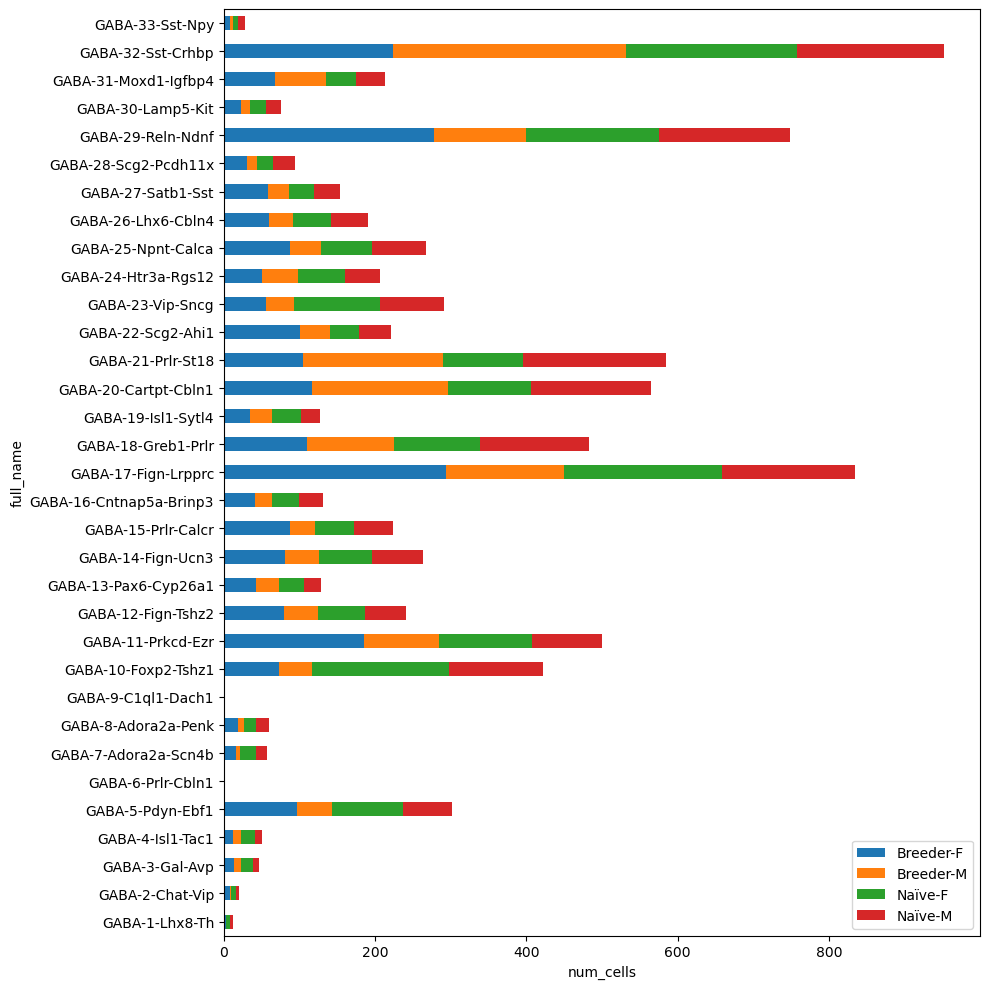

In [15]:
gaba_cluster_sex_stats_df.loc[:,['Breeder-F','Breeder-M','Naïve-F','Naïve-M']].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('num_cells')
plt.tight_layout()
#plt.savefig('/bigdata/isaac/gaba_files/sex_stats/int/gaba_cluster_counts.pdf')
plt.show()

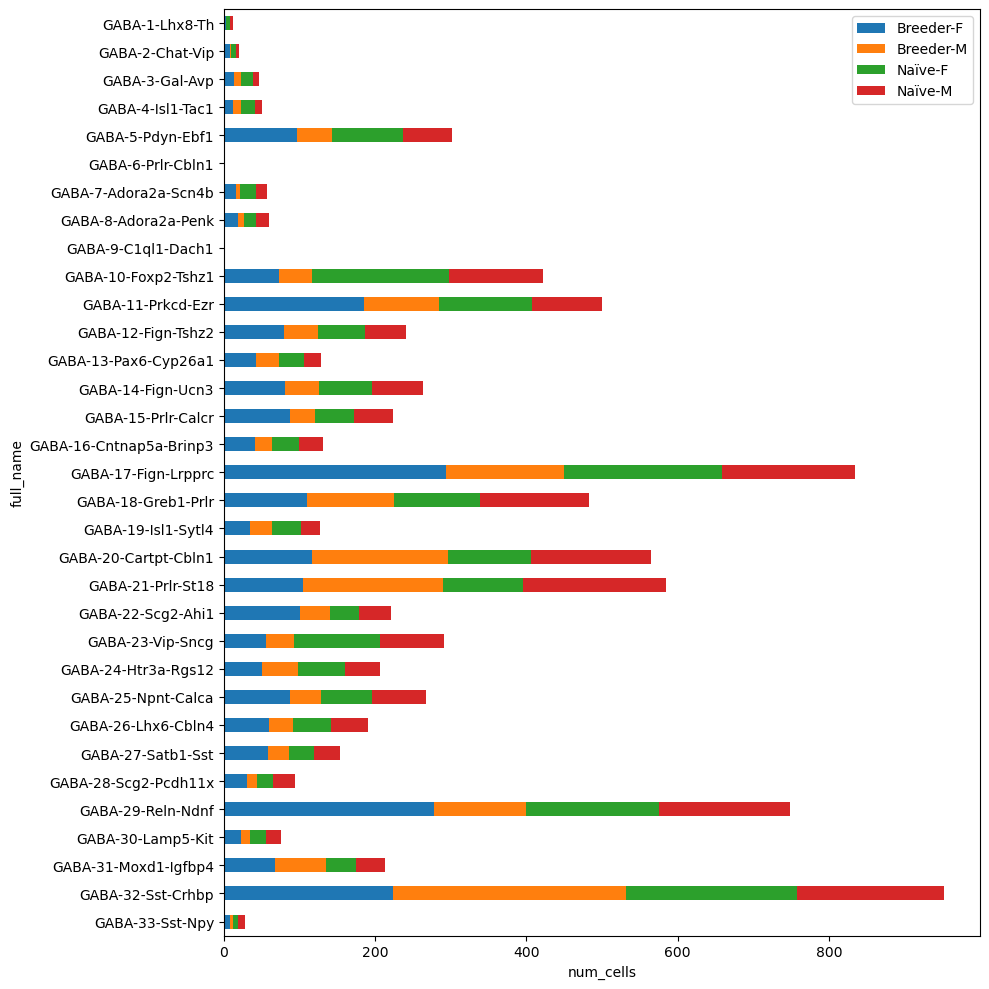

In [16]:
#reverse row order version
gaba_cluster_sex_stats_df.loc[:,['Breeder-F','Breeder-M','Naïve-F','Naïve-M']].iloc[::-1].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('num_cells')
plt.tight_layout()
#plt.savefig('/bigdata/isaac/gaba_files/sex_stats/int/gaba_cluster_counts_ro.pdf')
plt.show()

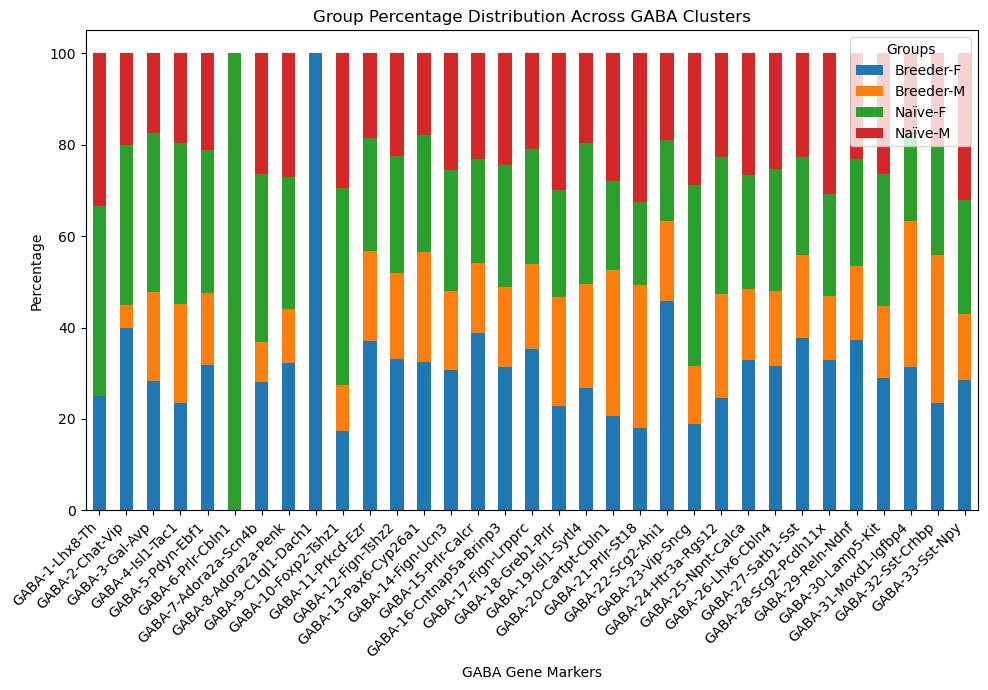

In [17]:
gaba_cluster_sex_stats_df_percentage = ss.compute_cluster_sex_stats(gaba_metadata_df, prc = True)
gaba_cluster_sex_stats_df_percentage = gaba_cluster_sex_stats_df_percentage.drop(columns=['num_sample_ids','sample_ids', 'num_cells'])
gaba_cluster_sex_stats_df_percentage.plot(kind='bar', stacked=True, figsize=(10, 7))
%matplotlib inline
plt.title('Group Percentage Distribution Across GABA Clusters')
plt.ylabel('Percentage')
plt.xlabel('GABA Gene Markers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Groups')
plt.tight_layout()
plt.show()

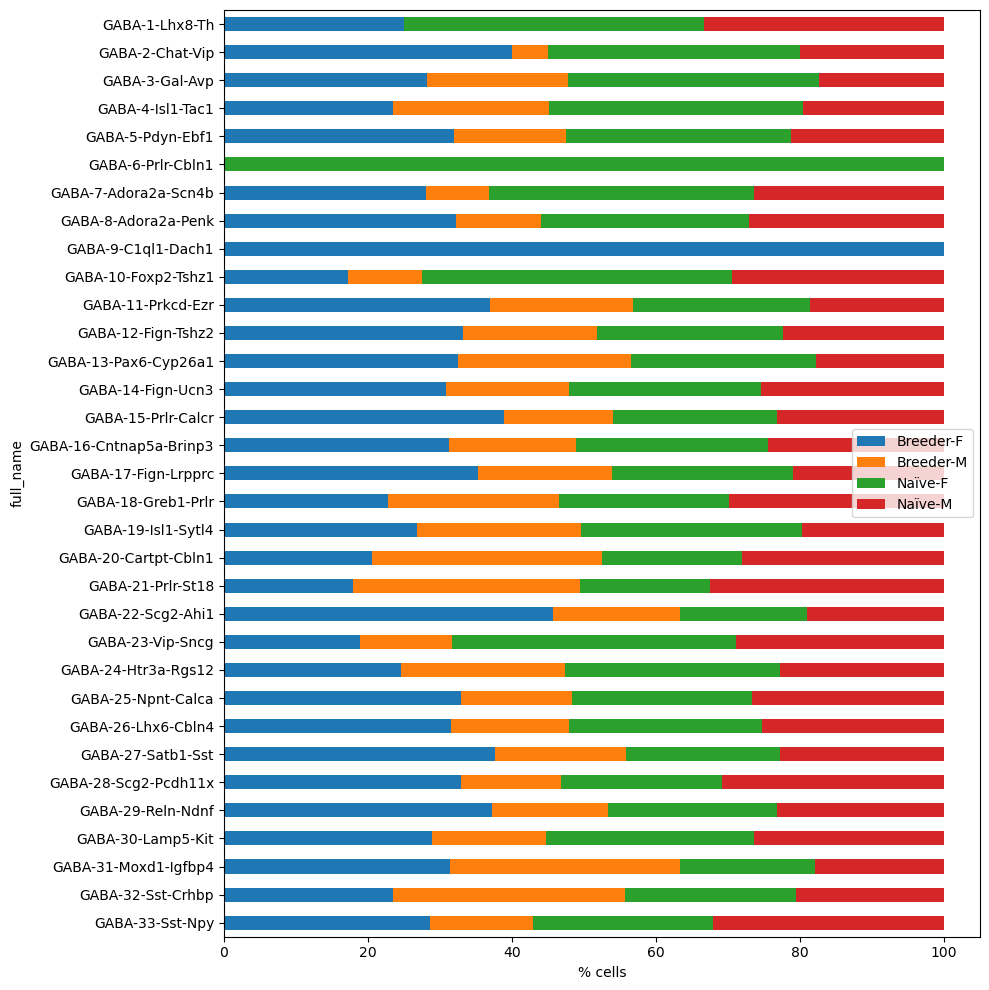

In [18]:

gaba_cluster_sex_stats_df_percentage.iloc[::-1].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('% cells')
plt.tight_layout()
plt.savefig('/bigdata/isaac/gaba_files/sex_stats/int/gaba_cluster_counts_ro_prc.pdf')
plt.show()

In [19]:
gaba_cluster_sex_stats_df.loc[:,'num_cells'].sum(axis=0)

8492

In [20]:
gaba_df_dlr, gaba_metadata_df_dlr, gaba_clusters_2_drop = ss.drop_low_representation_cts(gaba_cluster_sex_stats_df, df, gaba_metadata_df, min_cells=5, max_cells=None)

In [21]:
gaba_clusters_2_drop

['GABA-1-Lhx8-Th',
 'GABA-2-Chat-Vip',
 'GABA-6-Prlr-Cbln1',
 'GABA-9-C1ql1-Dach1',
 'GABA-33-Sst-Npy']

In [21]:
gaba_df_dlr.shape

(27874, 8430)

In [22]:
np.all(gaba_metadata_df_dlr.columns == gaba_df_dlr.columns)

True

In [23]:
gaba_clusters_2_drop

['GABA-1-Lhx8-Th',
 'GABA-2-Chat-Vip',
 'GABA-6-Prlr-Cbln1',
 'GABA-9-C1ql1-Dach1',
 'GABA-33-Sst-Npy']

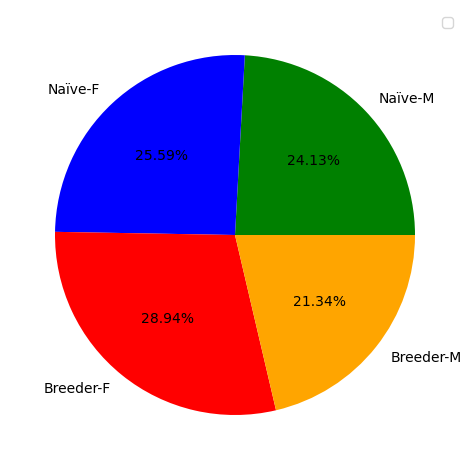

In [24]:
#check group representation at class level
gaba_class_sex_stats_df = ss.compute_class_sex_stats(gaba_metadata_df)
gaba_class_sex_stats_df_prc = gaba_class_sex_stats_df.drop(columns = ['num_sample_ids', 'sample_ids'])
gaba_class_sex_stats_df_prc.plot(kind = 'pie', subplots = True, colors = ['green','blue','red', 'orange'], autopct=lambda pct: f'{pct:.2f}%')
plt.legend([])
plt.ylabel('')
plt.tight_layout()
plt.savefig('/bigdata/isaac/gaba_files/sex_stats/int/gaba_group_prc_in_class.pdf')
plt.show()

### run sex stats pipeline

(27874, 334)
(334,)
(1, 334)
(7182, 334)


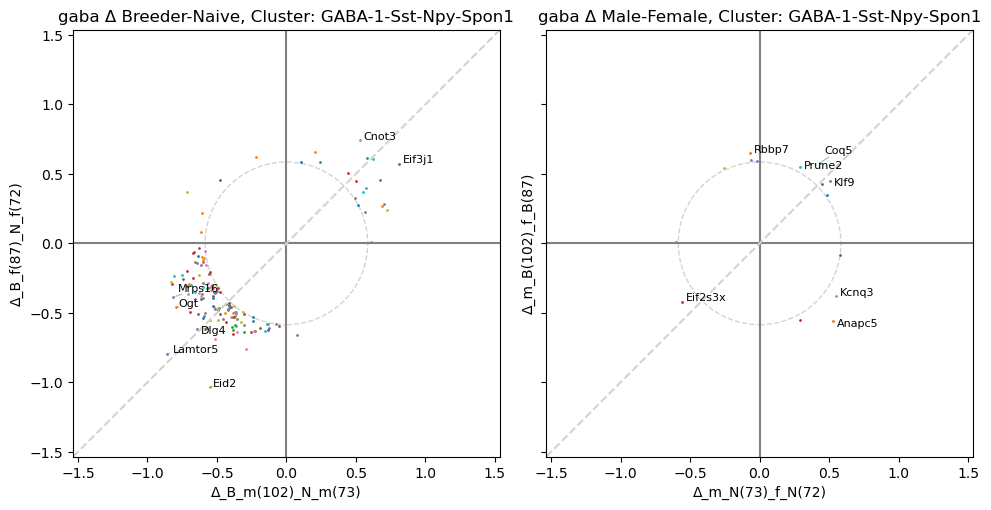

In [12]:
%matplotlib inline
#for delta plots debug/updates
cell_class = 'gaba'
run_folder = '/bigdata/isaac/'+cell_class+'_files/sex_stats/040325_run/'
delta_folder = run_folder + 'gene_delta_plots/'
_,counts_df = ss.compute_group_gene_expression_differences(gaba_df_dlr,
                                                                gaba_metadata_df_dlr,
                                                                cluster_fn='GABA-1-Sst-Npy-Spon1',
                                                                threshold_prc_h=70,
                                                                threshold_prc_l=10, 
                                                                r_bn = np.log2(1.5), 
                                                                r_mf = np.log2(1.5), 
                                                                cell_class=cell_class, 
                                                                folder = delta_folder,
                                                                gene_filtering=True,
                                                                normalize = True,
                                                                n_factor = 20000,          
                                                                mode = 'delta',
                                                                sig_genes_df = None,
                                                                savefig = False, 
                                                                write_to_file=False)

In [13]:
counts_df

,N_f_cnts,B_f_cnts,N_m_cnts,B_m_cnts
GABA-1-Sst-Npy-Spon1,72,87,73,102


In [14]:
delta_folder

'/bigdata/isaac/gaba_files/sex_stats/040325_run/gene_delta_plots/'

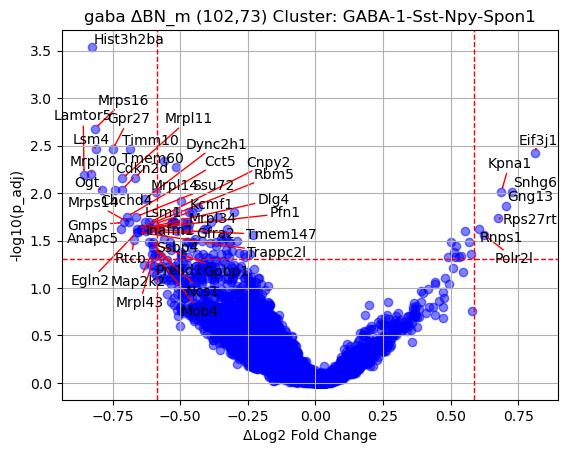

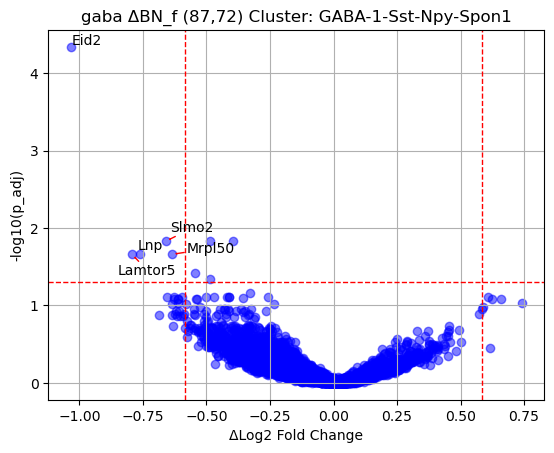

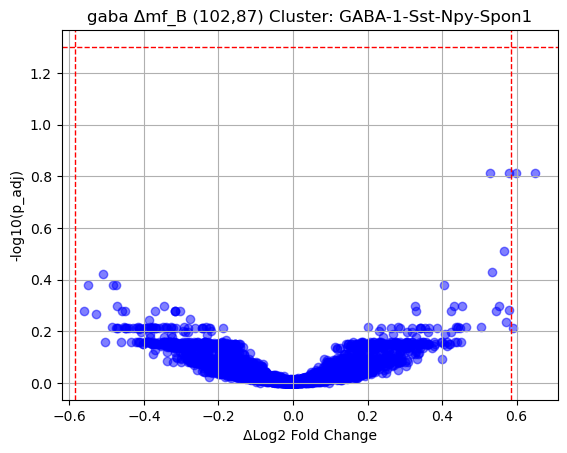

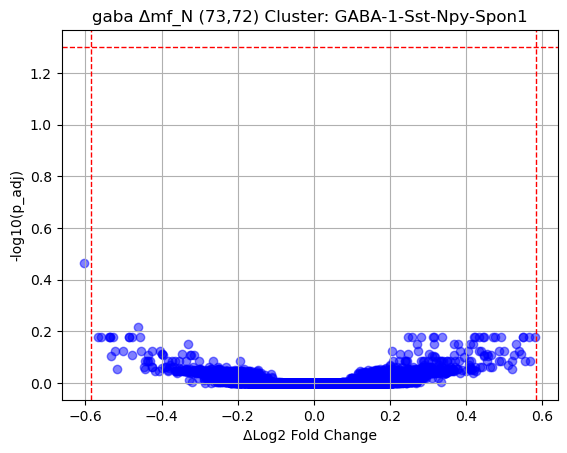

In [15]:
#debug volcano plots
delta_data_folder = delta_folder + 'data/'
utest_output_folder  = delta_folder + 'utest_data/'
volcano_output_folder = run_folder + 'volcano_plots/'
volcano_subfolders = ['data','plots']
c = 'GABA-1-Sst-Npy-Spon1'


_, _, _, _ = ss.run_volcano_analysis(delta_data_folder, utest_output_folder,volcano_output_folder, c, cell_class, counts_df, savefig = False, write_to_file = False)

In [25]:
%%capture output
#try with run sex stats
#folder dir setup
cell_class = 'gaba'
run_folder = '/bigdata/isaac/'+cell_class+'_files/sex_stats/int/110625_run/'
#261224_run fix border lines in volcano plots
run_subfolders = ['gene_delta_plots', 'volcano_plots','ct_bar_plots','sig_gene_heatmaps']
# create subfolder in delta folder
delta_folder = run_folder + 'gene_delta_plots/'

_ = rss.run_sex_stats(gaba_df_dlr,gaba_metadata_df_dlr,cell_class,run_folder,run_subfolders,delta_folder)



In [16]:
delta_folder

'/bigdata/isaac/gaba_files/sex_stats/040325_run/gene_delta_plots/'

In [29]:
run_folder

'/bigdata/isaac/Vglut2_files/sex_stats/311224_run/'

In [91]:
list(np.unique(gaba_metadata_df_dlr.loc['full_name',:]))

['GABA-1-Sst-Npy-Spon1',
 'GABA-10-Pax6-Npnt',
 'GABA-11-Pax6-Calca',
 'GABA-12-Sncg-Reln',
 'GABA-13-Fign-Lrpprc',
 'GABA-14-Isl1-Gal',
 'GABA-15-Igsf1-Zfhx3',
 'GABA-16-Lmo1-Chn2',
 'GABA-17-Isl1-Pou3f2',
 'GABA-18-Meis2-Dach1',
 'GABA-19-Meis2-Tshz1',
 'GABA-2-Sst-Npy-Maf',
 'GABA-20-Meis2-Foxp2',
 'GABA-21-Meis2-Nwd2',
 'GABA-22-Col23a1-Hs3st4',
 'GABA-23-Pde11a-Npy2r',
 'GABA-24-Prlr-St18',
 'GABA-25-Oprk1-Trhde',
 'GABA-26-Col18a1-Jsrp1',
 'GABA-27-Greb1-Dlk1',
 'GABA-28-Lypd1-Satb1',
 'GABA-29-Lpyd1-Unc13c',
 'GABA-3-Sst-Npy-Chodl',
 'GABA-30-Cbln4-Zbtb20',
 'GABA-31-Fign-Foxp2',
 'GABA-32-Cartpt-Dkk2',
 'GABA-33-Cartpt-Unc13c',
 'GABA-4-Moxd1-Pvalb',
 'GABA-5-Moxd1-Vwc2',
 'GABA-6-Hapln1-Cryab',
 'GABA-7-Vip-Crh',
 'GABA-8-Htr3a-Rgs12',
 'GABA-9-Dab1-Myh7']

In [85]:
for g in IEG_list:
    if g in gaba_df_dlr.index:
        pass
    else:   
        print(g)

In [ ]:
%%capture output
#IEG run (no gene filtering, IEGs included)

run_folder = '/bigdata/isaac/gaba_files/sex_stats/050325_run_IEG/'
delta_folder = run_folder + 'gene_delta_plots/'
volcano_output_folder = run_folder + 'volcano_plots/'
cell_class = 'gaba'


#list of gaba fns to generate formatted sig delta plots for
#gaba_fns = ['GABA-33-Cartpt-Unc13c', 'GABA-27-Greb1-Dlk1', 'GABA-24-Prlr-St18'] 
gaba_fns = list(np.unique(gaba_metadata_df_dlr.loc['full_name',:]))

#sig_genes_df = pd.read_csv(volcano_output_folder + 'sig_genes.csv',header=None)
for fn in gaba_fns:
    _,counts_df = ss.compute_group_gene_expression_differences(gaba_df_dlr,
                                                        gaba_metadata_df_dlr,
                                                        cluster_fn=fn,
                                                        threshold_prc_h=70,
                                                        threshold_prc_l=10, 
                                                        r_bn = np.log2(1.5), 
                                                        r_mf = np.log2(1.5), 
                                                        cell_class=cell_class, 
                                                        folder = delta_folder,
                                                        gene_filtering=False,
                                                        normalize = True,
                                                        n_factor = 20000,          
                                                        mode = 'delta',
                                                        sig_genes_df = None,
                                                        savefig = True, 
                                                        write_to_file=True)

FileNotFoundError: [Errno 2] No such file or directory: '/bigdata/isaac/gaba_files/sex_stats/050325_run_IEG/gene_delta_plots/plots/gaba_Gene_Delta_Plot_combined_c_GABA-1-Sst-Npy-Spon1.pdf'

In [83]:
delta_folder

'/bigdata/isaac/gaba_files/sex_stats/040325_run/gene_delta_plots/'

In [ ]:
colors = mpl.colormaps['tab20b'].colors

fig, ax = plt.subplots(layout='constrained')

for i, color in enumerate(colors):
    #print (i, color)
    if i in [1,5,13,19]:
        print (i, color)
        ax.plot([0, i], color=color)
plt.savefig(tmp_output_folder + 'colors.pdf')
plt.show()

<IPython.core.display.Javascript object>

1 (0.3215686274509804, 0.32941176470588235, 0.6392156862745098)
5 (0.5490196078431373, 0.6352941176470588, 0.3215686274509804)
14 (0.8392156862745098, 0.3803921568627451, 0.4196078431372549)
19 (0.8705882352941177, 0.6196078431372549, 0.8392156862745098)


# Vglut1 Analysis

In [22]:
np.log2(1.5)

0.5849625007211562

In [19]:
np.unique(meta_data_df.loc['cell_class',:])

array(['GABA', 'Vglut1', 'Vglut2'], dtype=object)

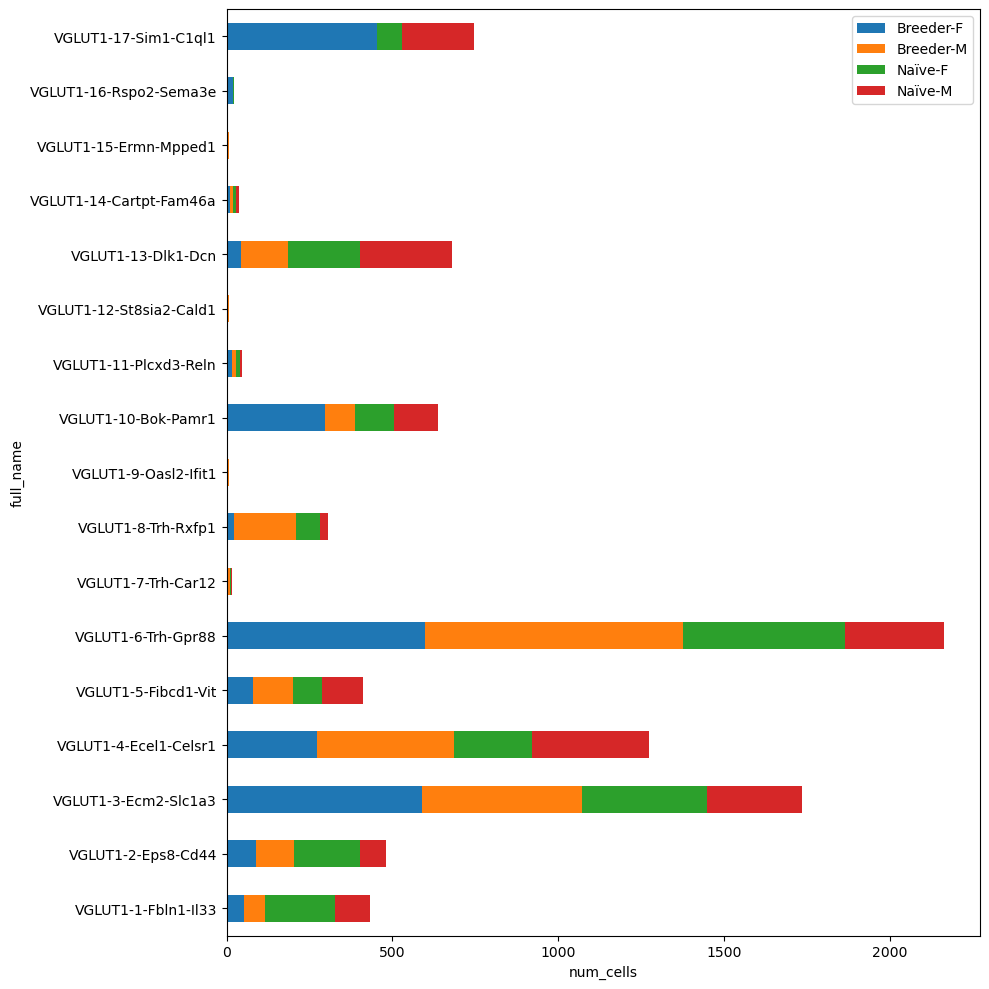

In [23]:
Vglut1_metadata_df = meta_data_df.loc[:,meta_data_df.loc['cell_class',:]=='VGLUT1']
Vglut1_cluster_sex_stats_df = ss.compute_cluster_sex_stats(Vglut1_metadata_df)
Vglut1_cluster_sex_stats_df.loc[:,['Breeder-F','Breeder-M','Naïve-F','Naïve-M']].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('num_cells')
plt.tight_layout()
#plt.savefig('/bigdata/isaac/Vglut1_files/sex_stats/int/vglut1_cluster_counts.pdf')
plt.show()

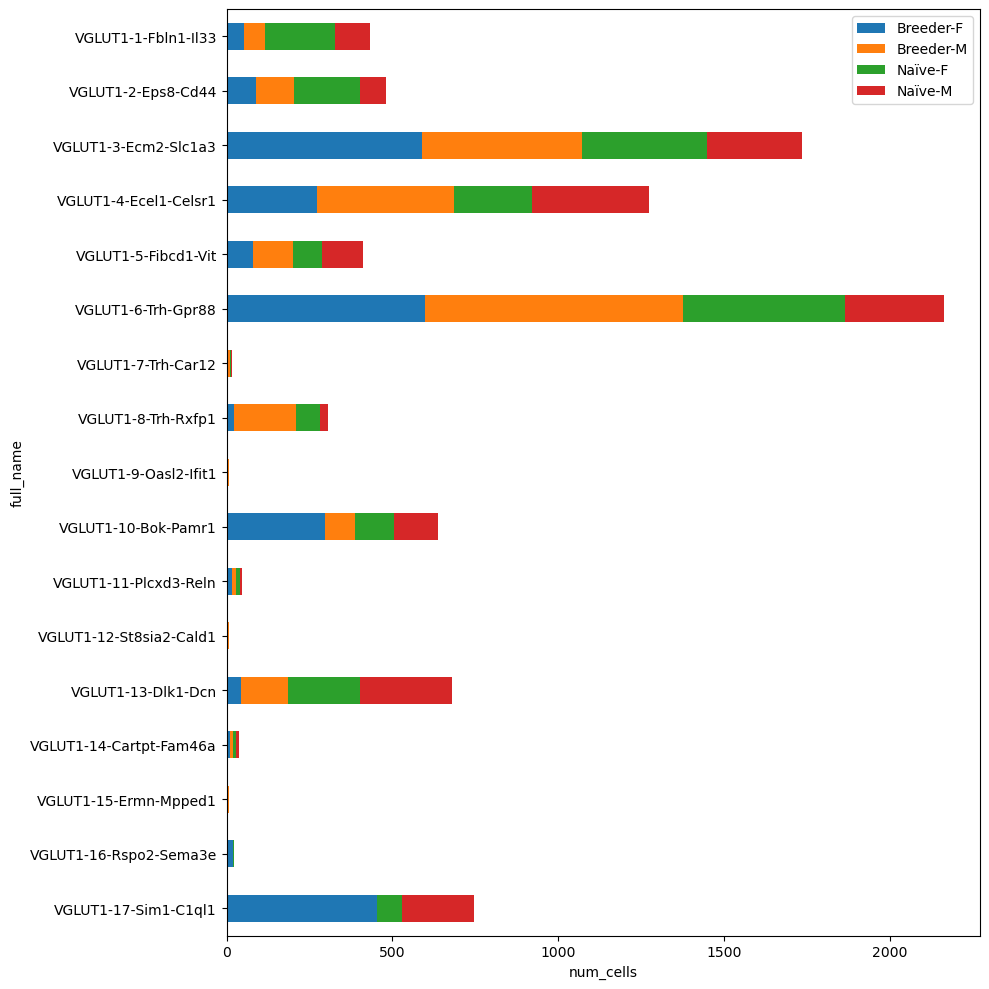

In [28]:
#reverse row order version
Vglut1_cluster_sex_stats_df.loc[:,['Breeder-F','Breeder-M','Naïve-F','Naïve-M']].iloc[::-1].plot.barh(stacked = True, figsize = (10,10))
%matplotlib inline
plt.xlabel('num_cells')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Vglut1_files/sex_stats/int/Vglut1_cluster_counts_ro.pdf')
plt.show()

In [11]:
Vglut1_cluster_sex_stats_df.loc[:,'num_cells'].sum(axis=0)

9019

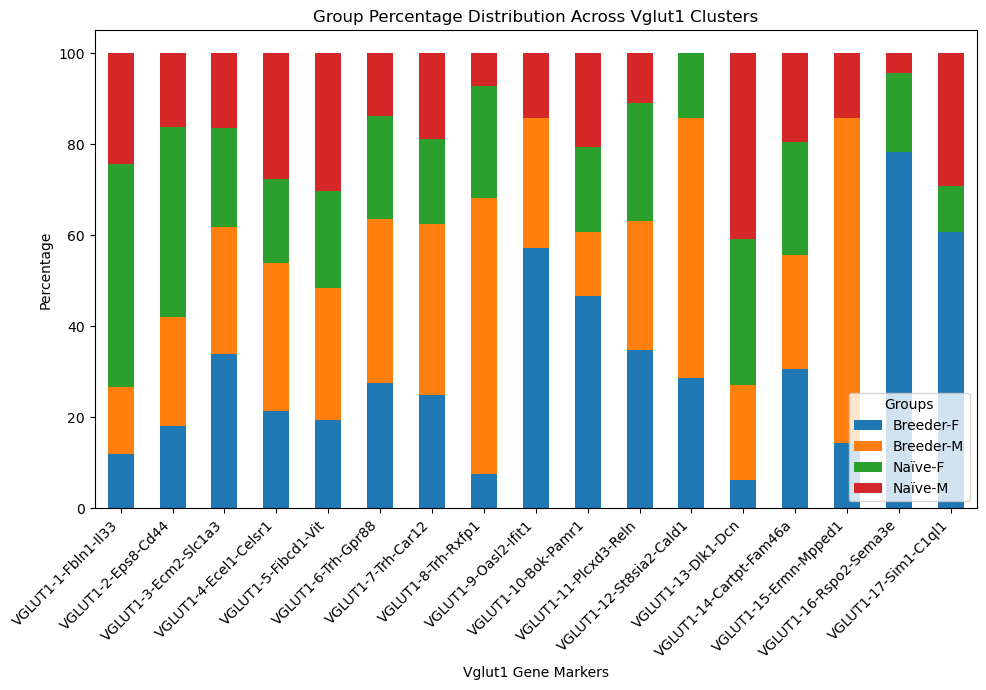

In [29]:
Vglut1_cluster_sex_stats_df_percentage = ss.compute_cluster_sex_stats(Vglut1_metadata_df, prc = True)
Vglut1_cluster_sex_stats_df_percentage = Vglut1_cluster_sex_stats_df_percentage.drop(columns=['num_sample_ids','sample_ids', 'num_cells'])
Vglut1_cluster_sex_stats_df_percentage.plot(kind='bar', stacked=True, figsize=(10, 7))
%matplotlib inline
plt.title('Group Percentage Distribution Across Vglut1 Clusters')
plt.ylabel('Percentage')
plt.xlabel('Vglut1 Gene Markers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Groups')
plt.tight_layout()
plt.show()

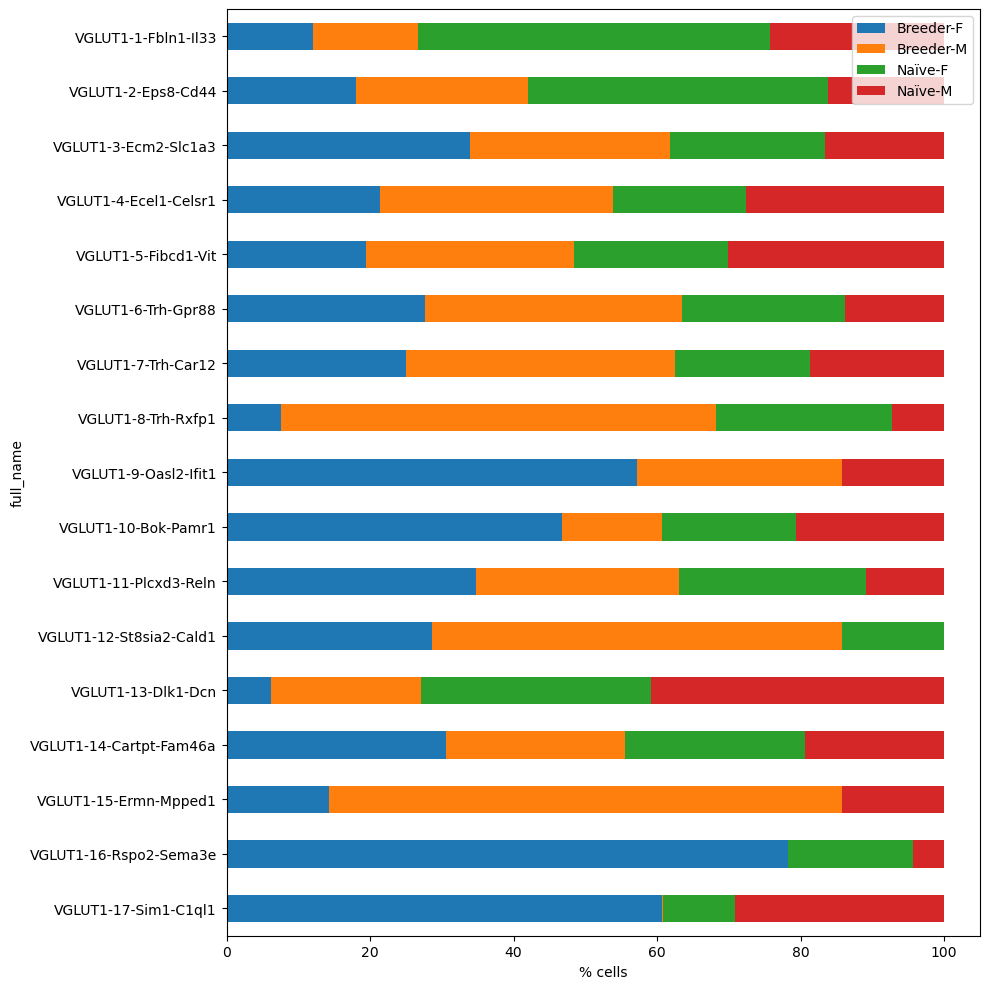

In [30]:

Vglut1_cluster_sex_stats_df_percentage.iloc[::-1].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('% cells')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Vglut1_files/sex_stats/int/Vglut1_cluster_counts_ro_prc.pdf')
plt.show()

In [18]:
Vglut1_df_dlr, Vglut1_metadata_df_dlr, Vglut1_clusters_2_drop = ss.drop_low_representation_cts(Vglut1_cluster_sex_stats_df, df, Vglut1_metadata_df, min_cells=5, max_cells=None)
Vglut1_clusters_2_drop

['VGLUT1-7-Trh-Car12',
 'VGLUT1-9-Oasl2-Ifit1',
 'VGLUT1-12-St8sia2-Cald1',
 'VGLUT1-15-Ermn-Mpped1',
 'VGLUT1-16-Rspo2-Sema3e',
 'VGLUT1-17-Sim1-C1ql1']

In [32]:
Vglut1_cluster_sex_stats_df

,Breeder-F,Breeder-M,Naïve-F,Naïve-M,num_cells,num_sample_ids,sample_ids
full_name,,,,,,,
VGLUT1-1-Fbln1-Il33,52,63,212,105,432,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT1-2-Eps8-Cd44,87,115,201,78,481,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT1-3-Ecm2-Slc1a3,588,484,376,287,1735,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT1-4-Ecel1-Celsr1,272,414,236,352,1274,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT1-5-Fibcd1-Vit,80,119,88,124,411,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT1-6-Trh-Gpr88,598,777,490,299,2164,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT1-7-Trh-Car12,4,6,3,3,16,9,"['10X35_1', '10X36_2', '10X37_1', '10X37_2', '..."
VGLUT1-8-Trh-Rxfp1,23,185,75,22,305,15,"['10X35_1', '10X35_2', '10X36_2', '10X37_1', '..."
VGLUT1-9-Oasl2-Ifit1,4,2,0,1,7,6,"['10X36_2', '10X51_1', '10X51_4', '10X52_1', '..."


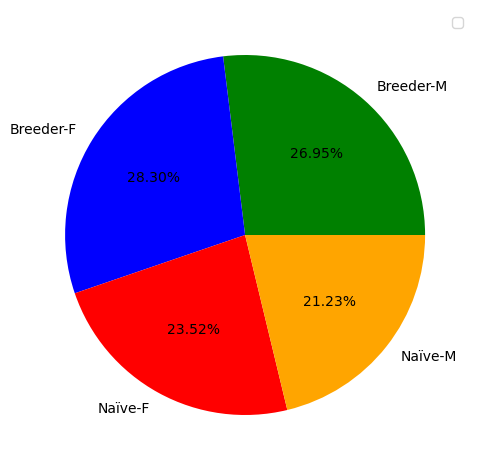

In [33]:
#check group representation at class level
Vglut1_class_sex_stats_df = ss.compute_class_sex_stats(Vglut1_metadata_df)
Vglut1_class_sex_stats_df_prc = Vglut1_class_sex_stats_df.drop(columns = ['num_sample_ids', 'sample_ids'])
Vglut1_class_sex_stats_df_prc.plot(kind = 'pie', subplots = True, colors = ['green','blue','red', 'orange'], autopct=lambda pct: f'{pct:.2f}%')
plt.legend([])
plt.ylabel('')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Vglut1_files/sex_stats/int/Vglut1_group_prc_in_class.pdf')
plt.show()

In [13]:
Vglut1_metadata_df_dlr.shape

(31, 8264)

In [27]:
np.all(Vglut1_metadata_df_dlr.columns == Vglut1_df_dlr.columns)

True

In [19]:
%%capture output
#folder dir setup
#2161224, remove cts with >500 cells in any group to avoid kernal crash
cell_class = 'Vglut1'
run_folder = '/bigdata/isaac/'+cell_class+'_files/sex_stats/int/110625_run/'
run_subfolders = ['gene_delta_plots', 'volcano_plots','ct_bar_plots','sig_gene_heatmaps']
# create subfolder in delta folder
delta_folder = run_folder + 'gene_delta_plots/'

_ = rss.run_sex_stats(Vglut1_df_dlr,Vglut1_metadata_df_dlr,cell_class,run_folder,run_subfolders,delta_folder)

In [94]:
%%capture output

#refine formatting sig gene plot
#sig gene delta delta plots
run_folder = '/bigdata/isaac/Vglut1_files/sex_stats/311224_run/'
volcano_output_folder = run_folder + 'volcano_plots/'
tmp_output_folder = '/bigdata/isaac/Vglut1_files/sex_stats/tmp/'
cell_class = 'Vglut1'

#list of Vglut1 fns to generate formatted sig delta plots for
#Vglut1_fns = ['Vglut1-12-Dlk1-Dcn',
#              'Vglut1-10-Ecel1-Sox5',
#              'Vglut1-7-Il33-Prox1',
#              'Vglut1-4-Snca-Satb2']
Vglut1_fns = list(np.unique(Vglut1_metadata_df_dlr.loc['full_name',:]))

sig_genes_df = pd.read_csv(volcano_output_folder + 'sig_genes.csv',header=None)
for fn in Vglut1_fns:
    _,counts_df = ss.compute_group_gene_expression_differences(Vglut1_df_dlr,
                                                        Vglut1_metadata_df_dlr,
                                                        cluster_fn=fn,
                                                        threshold_prc_h=70,
                                                        threshold_prc_l=10, 
                                                        r_bn = np.log2(1.5), 
                                                        r_mf = np.log2(1.5), 
                                                        cell_class=cell_class, 
                                                        folder = tmp_output_folder,
                                                        normalize = True,
                                                        n_factor = 20000,          
                                                        mode = 'sig_genes',
                                                        sig_genes_df = sig_genes_df,
                                                        savefig = True, 
                                                        write_to_file=False)

In [38]:
%%capture output
#run just for VGLUT1-17-Sim1-C1ql1 cell type, since it has sufficient samples 
#for male vs female naive, naive vs breeder female

Vglut1_sim1_metadata_df = Vglut1_metadata_df.loc[:,Vglut1_metadata_df.loc['full_name',:]=='VGLUT1-17-Sim1-C1ql1']
Vglut1_sim1_df = df.reindex(columns=Vglut1_sim1_metadata_df.columns)


#folder dir setup
#2161224, remove cts with >500 cells in any group to avoid kernal crash
cell_class = 'Vglut1'
run_folder = '/bigdata/isaac/'+cell_class+'_files/sex_stats/int/110625_run/'
run_subfolders = ['gene_delta_plots', 'volcano_plots','ct_bar_plots','sig_gene_heatmaps']
# create subfolder in delta folder
delta_folder = run_folder + 'gene_delta_plots/'

_ = rss.run_sex_stats(Vglut1_sim1_df,Vglut1_sim1_metadata_df,cell_class,run_folder,run_subfolders,delta_folder)


In [13]:
for g in IEG_list:
    if g in Vglut1_df_dlr.index:
        pass
    else:
        print (g)

# Vglut2

In [8]:
Vglut2_metadata_df = meta_data_df.loc[:,meta_data_df.loc['cell_class',:]=='VGLUT2']
Vglut2_cluster_sex_stats_df = ss.compute_cluster_sex_stats(Vglut2_metadata_df)
Vglut2_cluster_sex_stats_df.loc[:,['Breeder-F','Breeder-M','Naïve-F','Naïve-M']].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('num_cells')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Vglut2_files/sex_stats/int/Vglut2_cluster_counts.pdf')
plt.show()

<IPython.core.display.Javascript object>

In [9]:
#reverse row order version
Vglut2_cluster_sex_stats_df.loc[:,['Breeder-F','Breeder-M','Naïve-F','Naïve-M']].iloc[::-1].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('num_cells')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Vglut2_files/sex_stats/int/Vglut2_cluster_counts_ro.pdf')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

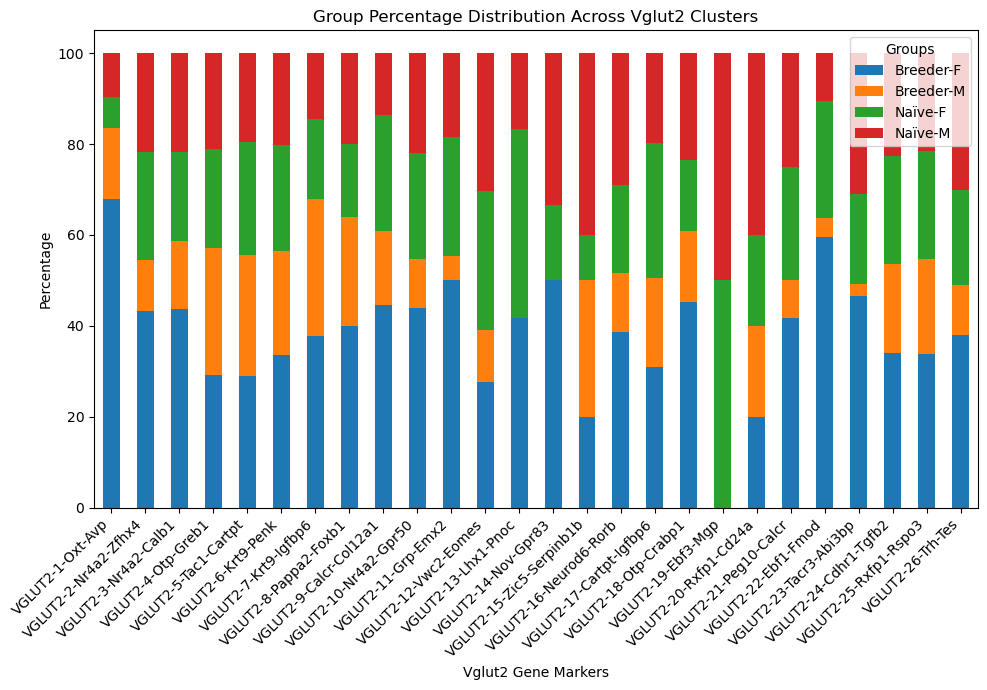

In [10]:
Vglut2_cluster_sex_stats_df_percentage = ss.compute_cluster_sex_stats(Vglut2_metadata_df, prc = True)
Vglut2_cluster_sex_stats_df_percentage = Vglut2_cluster_sex_stats_df_percentage.drop(columns=['num_sample_ids','sample_ids', 'num_cells'])
Vglut2_cluster_sex_stats_df_percentage.plot(kind='bar', stacked=True, figsize=(10, 7))
%matplotlib inline
plt.title('Group Percentage Distribution Across Vglut2 Clusters')
plt.ylabel('Percentage')
plt.xlabel('Vglut2 Gene Markers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Groups')
plt.tight_layout()
plt.show()

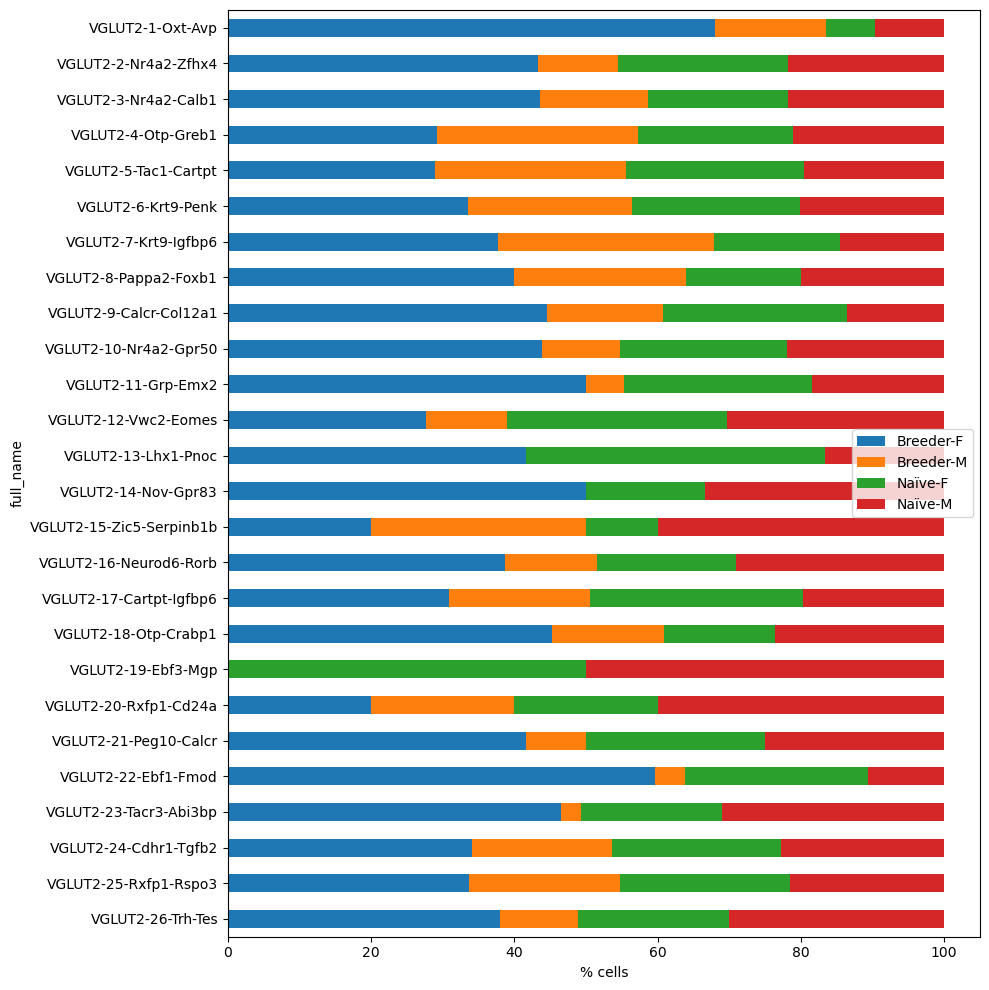

In [11]:
Vglut2_cluster_sex_stats_df_percentage.iloc[::-1].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('% cells')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Vglut2_files/sex_stats/int/Vglut2_cluster_counts_ro_prc.pdf')
plt.show()

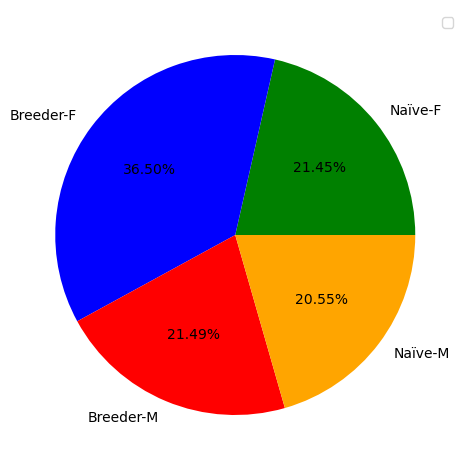

In [12]:
#check group representation at class level
Vglut2_class_sex_stats_df = ss.compute_class_sex_stats(Vglut2_metadata_df)
Vglut2_class_sex_stats_df_prc = Vglut2_class_sex_stats_df.drop(columns = ['num_sample_ids', 'sample_ids'])
Vglut2_class_sex_stats_df_prc.plot(kind = 'pie', subplots = True, colors = ['green','blue','red', 'orange'], autopct=lambda pct: f'{pct:.2f}%')
plt.legend([])
plt.ylabel('')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Vglut2_files/sex_stats/int/Vglut2_group_prc_in_class.pdf')
plt.show()

In [13]:
Vglut2_cluster_sex_stats_df

,Breeder-F,Breeder-M,Naïve-F,Naïve-M,num_cells,num_sample_ids,sample_ids
full_name,,,,,,,
VGLUT2-1-Oxt-Avp,70,16,7,10,103,14,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT2-2-Nr4a2-Zfhx4,119,31,65,60,275,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT2-3-Nr4a2-Calb1,58,20,26,29,133,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT2-4-Otp-Greb1,180,173,134,130,617,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT2-5-Tac1-Cartpt,185,170,159,125,639,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT2-6-Krt9-Penk,391,267,273,235,1166,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT2-7-Krt9-Igfbp6,455,363,212,176,1206,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
VGLUT2-8-Pappa2-Foxb1,10,6,4,5,25,14,"['10X35_2', '10X36_1', '10X36_2', '10X37_1', '..."
VGLUT2-9-Calcr-Col12a1,33,12,19,10,74,15,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."


In [65]:
Vglut2_cluster_sex_stats_df.loc[:,'num_cells'].sum(axis=0)

6788

In [14]:
#301224 - first pass, try keeping large cell types
#311224 - same issue as Vglut1 large cells, kernal crashes at Vglut2-9-Epha4-Penk
Vglut2_df_dlr, Vglut2_metadata_df_dlr, Vglut2_clusters_2_drop = ss.drop_low_representation_cts(Vglut2_cluster_sex_stats_df, df, Vglut2_metadata_df, min_cells=5, max_cells=None)
Vglut2_clusters_2_drop

['VGLUT2-8-Pappa2-Foxb1',
 'VGLUT2-11-Grp-Emx2',
 'VGLUT2-13-Lhx1-Pnoc',
 'VGLUT2-14-Nov-Gpr83',
 'VGLUT2-15-Zic5-Serpinb1b',
 'VGLUT2-16-Neurod6-Rorb',
 'VGLUT2-19-Ebf3-Mgp',
 'VGLUT2-20-Rxfp1-Cd24a',
 'VGLUT2-21-Peg10-Calcr',
 'VGLUT2-22-Ebf1-Fmod',
 'VGLUT2-23-Tacr3-Abi3bp']

In [15]:
%%capture output
cell_class = 'Vglut2'
run_folder = '/bigdata/isaac/'+cell_class+'_files/sex_stats/int/110625_run/'
run_subfolders = ['gene_delta_plots', 'volcano_plots','ct_bar_plots','sig_gene_heatmaps']
# create subfolder in delta folder
delta_folder = run_folder + 'gene_delta_plots/'

_ = rss.run_sex_stats(Vglut2_df_dlr,Vglut2_metadata_df_dlr,cell_class,run_folder,run_subfolders,delta_folder)

In [95]:
%%capture output
#refine formatting sig gene plot
#sig gene delta delta plots
run_folder = '/bigdata/isaac/Vglut2_files/sex_stats/311224_run/'
volcano_output_folder = run_folder + 'volcano_plots/'
tmp_output_folder = '/bigdata/isaac/Vglut2_files/sex_stats/tmp/'
cell_class = 'Vglut2'

#list of Vglut2 fns to generate formatted sig delta plots for
#Vglut2_fns = ['Vglut2-6-Otp-Zic5', 'Vglut2-5-Otp-Peg10']
Vglut2_fns = list(np.unique(Vglut2_metadata_df_dlr.loc['full_name',:]))

sig_genes_df = pd.read_csv(volcano_output_folder + 'sig_genes.csv',header=None)
for fn in Vglut2_fns:
    _,counts_df = ss.compute_group_gene_expression_differences(Vglut2_df_dlr,
                                                        Vglut2_metadata_df_dlr,
                                                        cluster_fn=fn,
                                                        threshold_prc_h=70,
                                                        threshold_prc_l=10, 
                                                        r_bn = np.log2(1.5), 
                                                        r_mf = np.log2(1.5), 
                                                        cell_class=cell_class, 
                                                        folder = tmp_output_folder,
                                                        normalize = True,
                                                        n_factor = 20000,          
                                                        mode = 'sig_genes',
                                                        sig_genes_df = sig_genes_df,
                                                        savefig = True, 
                                                        write_to_file=False)

# nonneuronal analysis

In [3]:
NN_filtered_folder = '/bigdata/isaac/Nonneuronal_files/filtered_merged/'
NN_metadata_df = pd.read_json(NN_filtered_folder  + 'NNmeta_data_df_plis_f_markers_2025-04-14.json')

In [8]:
NN_df = df_orig.reindex(columns=NN_metadata_df.columns)
#remove sex genes, IEG genes
NN_df = dp.gene_remover(sex_gene_list,NN_df)
NN_df = dp.gene_remover(IEG_list,NN_df)

removing  6  genes found in  ['Xist', 'Tsix', 'Ddx3y', 'Eif2s3y', 'Kdm5d', 'Uty']
removing  53  genes found in  ['Btg2', 'Jun', 'Egr4', 'Fosb', 'Junb', 'Gadd45g', 'Fos', 'Arc', 'Nr4a1', 'Npas4', 'Coq10b', 'Tns1', 'Per2', 'Ptgs2', 'Rnd3', 'Tnfaip6', 'Srxn1', 'Tiparp', 'Ccnl1', 'Mcl1', 'Dnajb5', 'Nr4a3', 'Fosl2', 'Nptx2', 'Rasl11a', 'Mest', 'Sertad1', 'Egr2', 'Midn', 'Gadd45b', 'Dusp6', 'Irs2', 'Plat', 'Ier2', 'Rrad', 'Tpbg', 'Csrnp1', 'Peli1', 'Per1', 'Kdm6b', 'Inhba', 'Plk2', 'Ifrd1', 'Baz1a', 'Trib1', 'Pim3', 'Lrrk2', 'Dusp1', 'Cdkn1a', 'Pim1', 'Sik1', 'Frat2', 'Dusp5']


In [39]:
Counter(NN_metadata_df.loc['markers',:])

Counter({'Astro': 3718,
         'OL_1': 2284,
         'OPC_1': 2057,
         'Microglia': 1338,
         'Endothelial': 962,
         'Pericyte': 959,
         'OL_2': 251,
         'VSM': 207,
         'Astro_gfap': 196,
         'OPC_2': 146,
         'PVM': 84,
         'Fibroblast': 66,
         'Proliferating_cells': 59,
         'Erythrocyte': 39,
         'Epend': 32})

In [30]:
NN_metadata_df.shape

(31, 12398)

In [31]:
NN_df

,GATCCCTCAATACGCT-1_10X38_2,TGATGGTCACAAGCCC-1_10X37_1,GGGTGAATCAAACGTC-1_10X38_1,TAACGACAGGATCACG-1_10X37_1,AGCGTATTCCGCAACG-1_10X38_2,GCAGGCTCACTCCTGT-1_10X38_2,ATGATCGGTCTGTCCT-1_10X38_2,TGATTCTAGTTTCGGT-1_10X38_1,AATAGAGGTTCATCGA-1_10X37_1,CATCGTCCAGTTACCA-1_10X51_2,...,GCACGTGGTTATTCCT-1_10X37_1,CAAGAGGGTCAATCTG-1_10X36_2,GGTGTCGAGAAGCTGC-1_10X36_2,AAGCCATGTGGATGAC-1_10X35_1,TTCTTCCCAAGACCTT-1_10X35_1,GAGAGGTCACATCATG-1_10X37_2,ATCAGGTTCCACTAGA-1_10X35_2,TCCACGTAGAGCATCG-1_10X37_1,CTGCGAGCACTACGGC-1_10X35_2,CTCTGGTTCGAAGCAG-1_10X37_1
gene,,,,,,,,,,,,,,,,,,,,,
0610007P14Rik,0,0,2,0,0,0,0,1,0,0,...,2,2,3,2,2,3,1,0,3,2
0610009B22Rik,1,0,4,0,0,2,0,1,0,1,...,0,0,0,0,0,0,0,0,1,2
0610009L18Rik,2,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
0610009O20Rik,0,0,2,0,0,2,0,0,1,0,...,1,0,0,0,1,0,1,0,0,0
0610010F05Rik,0,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mt-Nd3,18,7,33,13,12,24,4,10,7,24,...,33,16,16,17,21,32,16,24,22,39
mt-Nd4,35,24,162,43,33,112,18,29,15,34,...,147,230,75,97,104,106,59,95,87,126
mt-Nd4l,1,2,10,5,2,5,2,0,3,5,...,9,8,6,5,4,14,5,5,4,6


In [ ]:
NN_cluster_sex_stats_df = ss.compute_cluster_sex_stats(NN_metadata_df)
NN_cluster_sex_stats_df.loc[:,['Breeder-F','Breeder-M','Naïve-F','Naïve-M']].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('num_cells')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Nonneuronal_files/sex_stats/NN_cluster_counts.pdf')
plt.show()

<IPython.core.display.Javascript object>

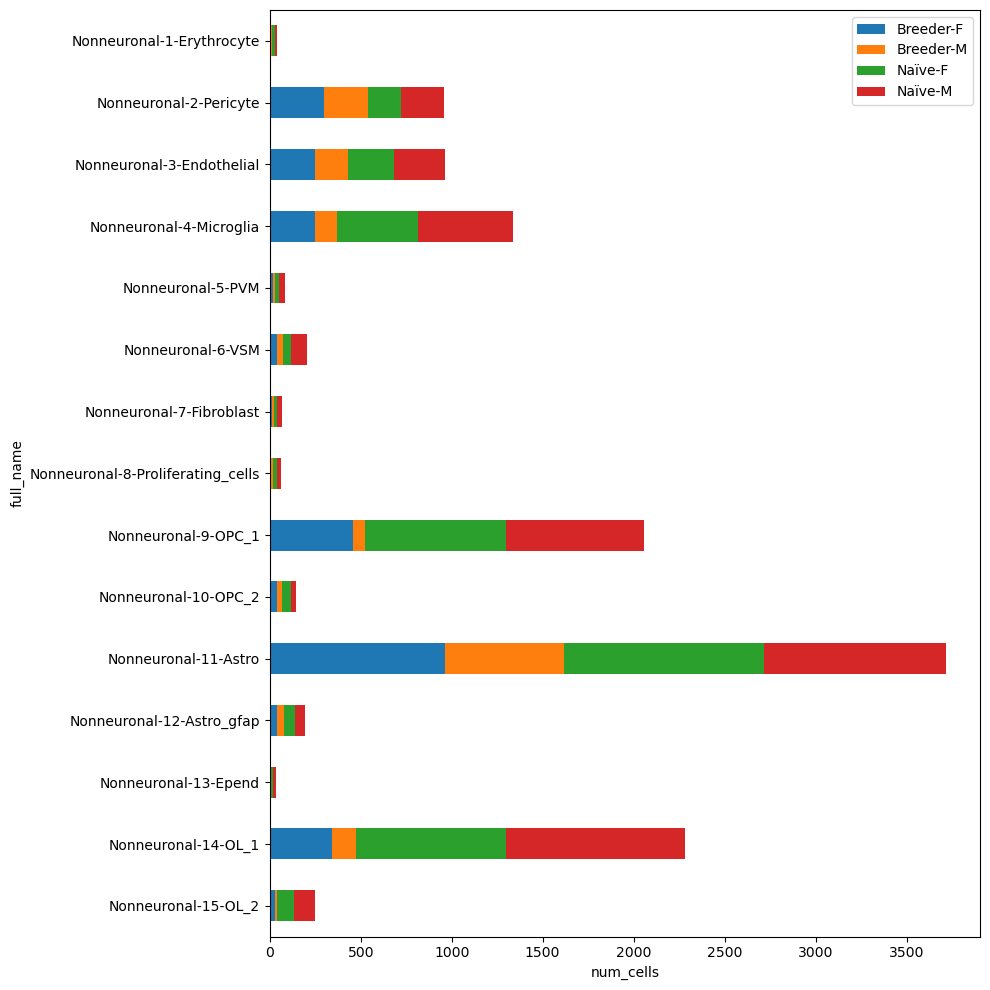

In [33]:
#reverse row order version
%matplotlib inline
NN_cluster_sex_stats_df.loc[:,['Breeder-F','Breeder-M','Naïve-F','Naïve-M']].iloc[::-1].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('num_cells')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Nonneuronal_files/sex_stats/NN_cluster_counts_ro.pdf')
plt.show()

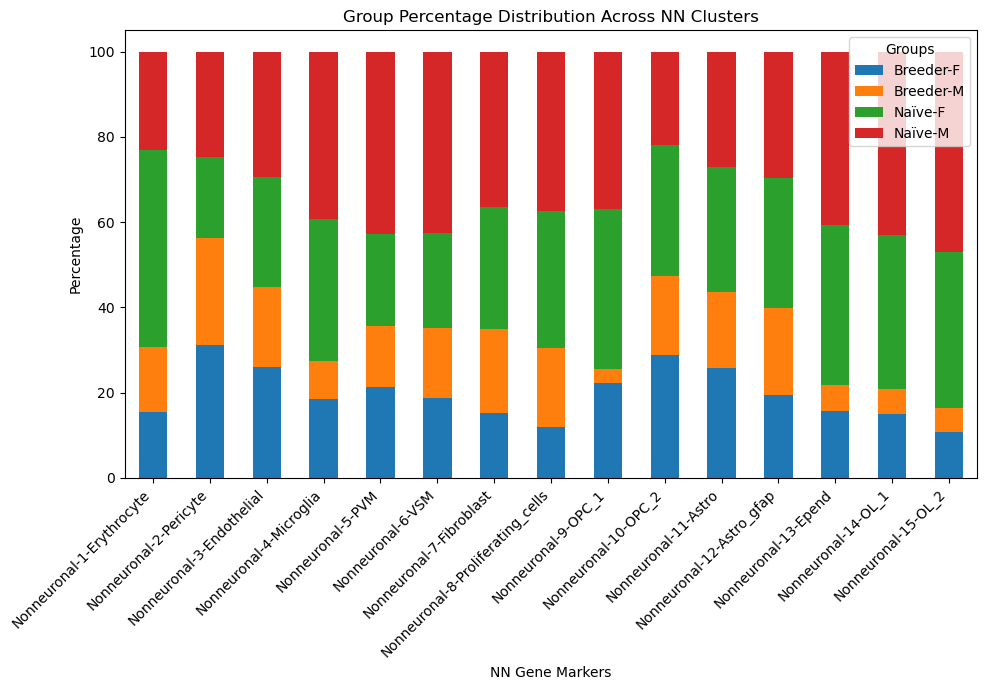

In [100]:
NN_cluster_sex_stats_df_percentage = ss.compute_cluster_sex_stats(NN_metadata_df, prc = True)
NN_cluster_sex_stats_df_percentage = NN_cluster_sex_stats_df_percentage.drop(columns=['num_sample_ids','sample_ids', 'num_cells'])
NN_cluster_sex_stats_df_percentage.plot(kind='bar', stacked=True, figsize=(10, 7))
%matplotlib inline
plt.title('Group Percentage Distribution Across NN Clusters')
plt.ylabel('Percentage')
plt.xlabel('NN Gene Markers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Groups')
plt.tight_layout()
plt.show()

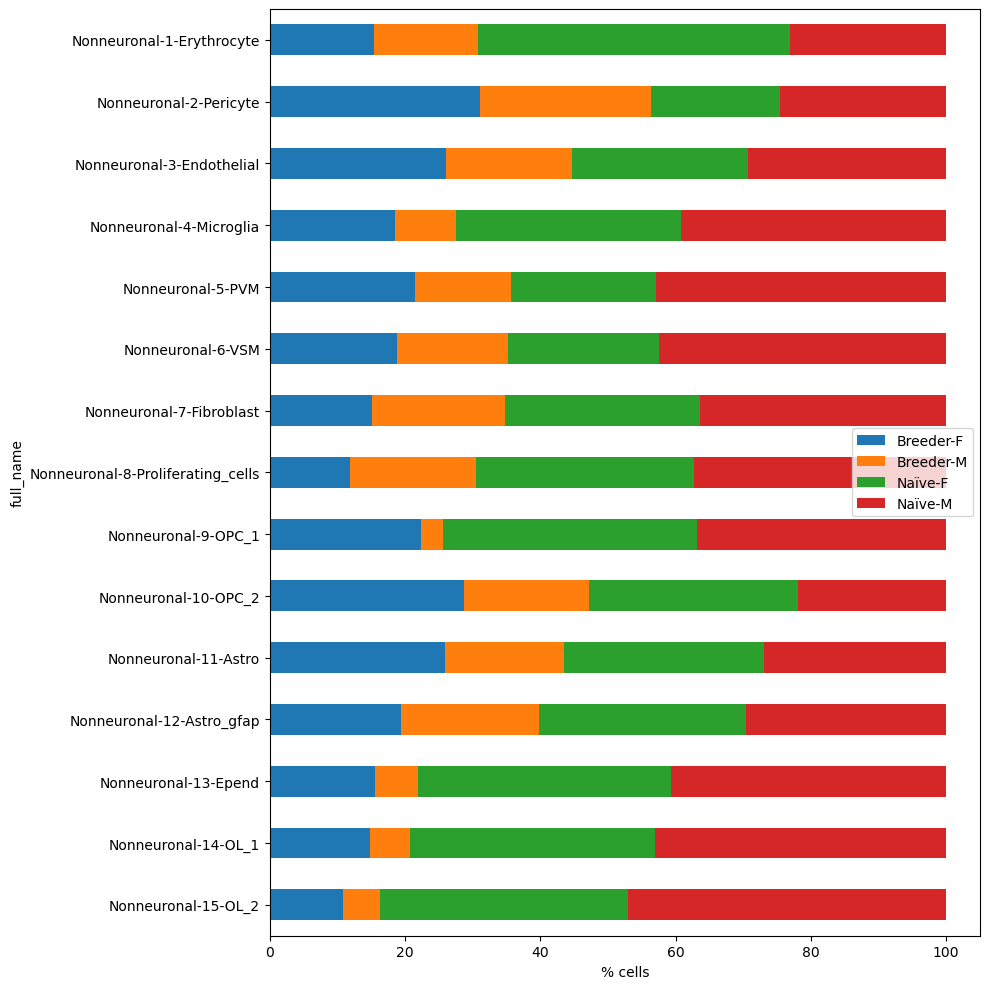

In [35]:
NN_cluster_sex_stats_df_percentage.iloc[::-1].plot.barh(stacked = True, figsize = (10,10))
plt.xlabel('% cells')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Nonneuronal_files/sex_stats/NN_cluster_counts_ro_prc.pdf')
plt.show()

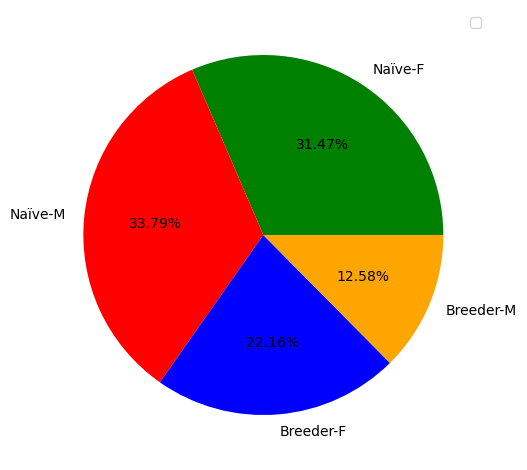

In [38]:
#check group representation at class level
NN_class_sex_stats_df = ss.compute_class_sex_stats(NN_metadata_df)
NN_class_sex_stats_df_prc = NN_class_sex_stats_df.drop(columns = ['num_sample_ids', 'sample_ids'])
NN_class_sex_stats_df_prc.plot(kind = 'pie', subplots = True, colors = ['green','red','blue', 'orange'], autopct=lambda pct: f'{pct:.2f}%')
plt.legend([])
plt.ylabel('')
plt.tight_layout()
plt.savefig('/bigdata/isaac/Nonneuronal_files/sex_stats/NN_group_prc_in_class.pdf')
plt.show()

In [37]:
NN_class_sex_stats_df_prc

,prc
Naïve-F,31.47
Naïve-M,33.79
Breeder-F,22.16
Breeder-M,12.58


In [14]:
NN_cluster_sex_stats_df

,Breeder-F,Breeder-M,Naïve-F,Naïve-M,num_cells,num_sample_ids,sample_ids
full_name,,,,,,,
Nonneuronal-1-OL_1,13,11,31,43,98,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-2-OL_2,21,3,51,44,119,14,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-3-OL_3,22,5,34,26,87,14,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-4-Epend,4,1,9,11,25,9,"['10X35_1', '10X35_2', '10X36_1', '10X37_1', '..."
Nonneuronal-5-Astro_gfap,13,18,32,31,94,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-6-Astro,89,91,72,74,326,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-7-Proliferating_cells,3,4,14,16,37,14,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-8-OPC,40,2,147,36,225,12,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-9-Microglia,8,5,20,24,57,12,"['10X35_1', '10X35_2', '10X36_1', '10X37_1', '..."


In [40]:
NN_df_dlr, NN_metadata_df_dlr, NN_clusters_2_drop = ss.drop_low_representation_cts(NN_cluster_sex_stats_df, NN_df, NN_metadata_df, min_cells=5, max_cells=None)
NN_clusters_2_drop

['Nonneuronal-13-Epend']

In [41]:
NN_df.shape

(27874, 12398)

In [42]:
NN_df_dlr.shape

(27874, 12366)

In [43]:
%%capture output
cell_class = 'Nonneuronal'
run_folder = '/bigdata/isaac/'+cell_class+'_files/sex_stats/150425_run/'
run_subfolders = ['gene_delta_plots', 'volcano_plots','ct_bar_plots','sig_gene_heatmaps']
# create subfolder in delta folder
delta_folder = run_folder + 'gene_delta_plots/'

_ = rss.run_sex_stats(NN_df_dlr,NN_metadata_df_dlr,cell_class,run_folder,run_subfolders,delta_folder)

Check breakdown of each cell type by sample

In [9]:
NN_metadata_df

,GATCCCTCAATACGCT-1_10X38_2,TGATGGTCACAAGCCC-1_10X37_1,GGGTGAATCAAACGTC-1_10X38_1,TAACGACAGGATCACG-1_10X37_1,AGCGTATTCCGCAACG-1_10X38_2,GCAGGCTCACTCCTGT-1_10X38_2,ATGATCGGTCTGTCCT-1_10X38_2,TGATTCTAGTTTCGGT-1_10X38_1,AATAGAGGTTCATCGA-1_10X37_1,CATCGTCCAGTTACCA-1_10X51_2,...,GCACGTGGTTATTCCT-1_10X37_1,CAAGAGGGTCAATCTG-1_10X36_2,GGTGTCGAGAAGCTGC-1_10X36_2,AAGCCATGTGGATGAC-1_10X35_1,TTCTTCCCAAGACCTT-1_10X35_1,GAGAGGTCACATCATG-1_10X37_2,ATCAGGTTCCACTAGA-1_10X35_2,TCCACGTAGAGCATCG-1_10X37_1,CTGCGAGCACTACGGC-1_10X35_2,CTCTGGTTCGAAGCAG-1_10X37_1
Serial_Number,70.0,67.0,69.0,67.0,70.0,70.0,70.0,69.0,67.0,98.0,...,67.0,66.0,66.0,63.0,63.0,68.0,64.0,67.0,64.0,67.0
Date_Captured,2019-12-01,2019-11-25,2019-12-01,2019-11-25,2019-12-01,2019-12-01,2019-12-01,2019-12-01,2019-11-25,05/31/20,...,2019-11-25,2019-11-24,2019-11-24,2019-11-20,2019-11-20,2019-11-25,2019-11-20,2019-11-25,2019-11-20,2019-11-25
Species,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,...,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm
Transcriptome,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,...,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10
Strain,,,,,,,,,,C57Bl/6,...,,,,,,,,,,
Project,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,...,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph
Group,Naïve-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Naïve-F,Naïve-F,Naïve-F,Naïve-M,Breeder-F,...,Naïve-M,Naïve-M,Naïve-M,Naïve-F,Naïve-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Naïve-M
ChipID,10X38,10X37,10X38,10X37,10X38,10X38,10X38,10X38,10X37,10X51,...,10X37,10X36,10X36,10X35,10X35,10X37,10X35,10X37,10X35,10X37
SampleID,10X38_2,10X37_1,10X38_1,10X37_1,10X38_2,10X38_2,10X38_2,10X38_1,10X37_1,10X51_2,...,10X37_1,10X36_2,10X36_2,10X35_1,10X35_1,10X37_2,10X35_2,10X37_1,10X35_2,10X37_1
DonorID,DI6,"DI4,DI5",DI6,"DI4,DI5",DI6,DI6,DI6,DI6,"DI4,DI5",DI-B1-F,...,"DI4,DI5",DI3,DI3,"DI1,DI2","DI1,DI2","DI4,DI5","DI1,DI2","DI4,DI5","DI1,DI2","DI4,DI5"


In [12]:
NN_cluster_sex_stats_df

,Breeder-F,Breeder-M,Naïve-F,Naïve-M,num_cells,num_sample_ids,sample_ids
full_name,,,,,,,
Nonneuronal-1-Erythrocyte,6,6,18,9,39,9,"['10X36_1', '10X37_1', '10X37_2', '10X38_1', '..."
Nonneuronal-2-Pericyte,298,242,183,236,959,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-3-Endothelial,250,180,250,282,962,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-4-Microglia,247,121,445,525,1338,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-5-PVM,18,12,18,36,84,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-6-VSM,39,34,46,88,207,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-7-Fibroblast,10,13,19,24,66,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-8-Proliferating_cells,7,11,19,22,59,15,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-9-OPC_1,459,67,772,759,2057,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."


In [21]:
NN_metadata_df.loc['SampleID',(NN_metadata_df.loc['full_name']=='Nonneuronal-14-OL_1') 
                   & (NN_metadata_df.loc['Group']=='Breeder-M')]

GAGTGAGTCCCTCTCC-1_10X52_3    10X52_3
TGATTTCTCCCATGGG-1_10X51_4    10X51_4
TTTCACACATGGCACC-1_10X52_4    10X52_4
CCCGGAACAATAACGA-1_10X52_3    10X52_3
AGTCTCCTCTCCTACG-1_10X52_3    10X52_3
                               ...   
GTATTTCCACTAACCA-1_10X51_4    10X51_4
TCGCACTAGATGGTAT-1_10X51_4    10X51_4
TACGTCCGTTCCTTGC-1_10X52_4    10X52_4
AGTACCACACTGGATT-1_10X51_4    10X51_4
CTTAGGATCGTCGATA-1_10X51_4    10X51_4
Name: SampleID, Length: 134, dtype: object

In [58]:
groups = np.unique(NN_metadata_df.loc['Group'])
groups

array(['Breeder-F', 'Breeder-M', 'Naïve-F', 'Naïve-M'], dtype=object)

array(['10X35_1', '10X35_2', '10X36_1', '10X36_2', '10X37_1', '10X37_2',
       '10X38_1', '10X38_2', '10X51_1', '10X51_2', '10X51_3', '10X51_4',
       '10X52_1', '10X52_2', '10X52_3', '10X52_4'], dtype=object)

In [ ]:
Counter(NN_metadata_df.loc['SampleID',(NN_metadata_df.loc['full_name']=='Nonneuronal-14-OL_1') 
                   & (NN_metadata_df.loc['Group']=='Breeder-M')])

Counter({'10X52_3': 68, '10X52_4': 30, '10X51_4': 26, '10X51_3': 10})

In [56]:
OL_1_breeder_m_sample_ids_counts = Counter(NN_metadata_df.loc['SampleID',(NN_metadata_df.loc['full_name']=='Nonneuronal-14-OL_1') 
                   & (NN_metadata_df.loc['Group']=='Breeder-M')])

In [53]:
sorted(OL_1_breeder_m_sample_ids_counts.items())

[('10X51_3', 10), ('10X51_4', 26), ('10X52_3', 68), ('10X52_4', 30)]

array([[0.22352941, 0.23137255, 0.4745098 , 1.        ],
       [0.70980392, 0.81176471, 0.41960784, 1.        ],
       [0.67843137, 0.28627451, 0.29019608, 1.        ],
       [0.87058824, 0.61960784, 0.83921569, 1.        ]])

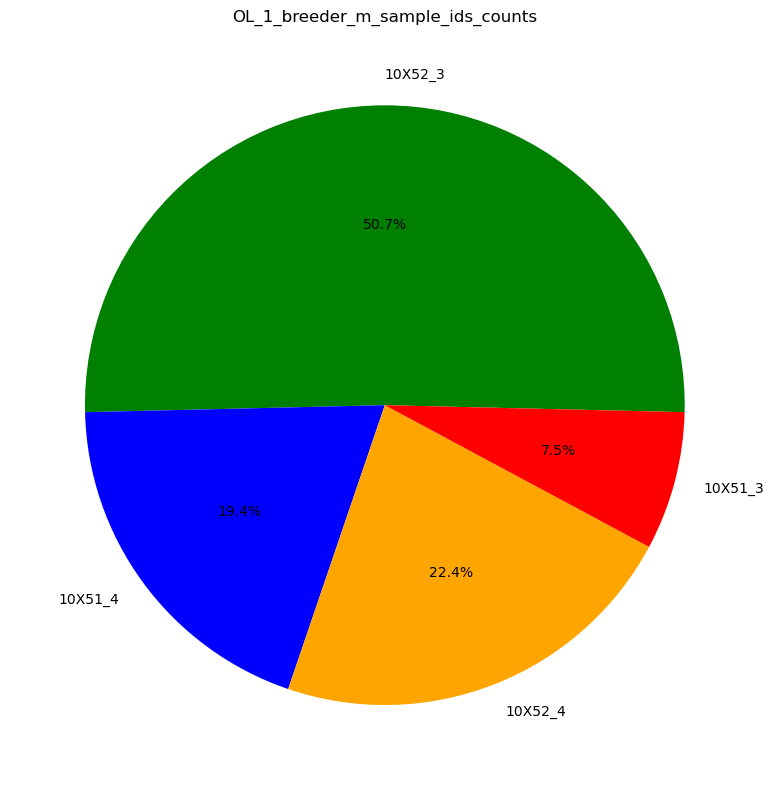

In [57]:
%matplotlib inline
# Extract labels and sizes
labels = list(OL_1_breeder_m_sample_ids_counts.keys())
sizes = list(OL_1_breeder_m_sample_ids_counts.values())

label_colors = {
    '10X51_3': 'red',
    '10X51_4': 'blue',
    '10X52_3': 'green',
    '10X52_4': 'orange'
}

# Define a reference label and its desired position (e.g., top center at 90 degrees)
reference_label = '10X52_3'
reference_angle = 90  # Desired angle for the reference label

# Calculate the startangle to align the reference label
reference_index = labels.index(reference_label)
cumulative_sizes = sum(sizes[:reference_index]) + sizes[reference_index] / 2
startangle = reference_angle - (cumulative_sizes / sum(sizes)) * 360



# Map the colors to the labels
colors = [label_colors[label] for label in labels]
#print (sorted(labels))
# Plot pie chart
plt.figure(figsize=(8, 8))
#colors = plt.cm.tab20b(np.linspace(0, 1, len(sorted(labels))))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=startangle, colors=colors)
plt.title('OL_1_breeder_m_sample_ids_counts')
plt.tight_layout()
plt.show()

In [37]:
OPC_1_breeder_m_sample_ids_cts = Counter(NN_metadata_df.loc['SampleID',(NN_metadata_df.loc['full_name']=='Nonneuronal-9-OPC_1') 
                   & (NN_metadata_df.loc['Group']=='Breeder-M')])

In [38]:
OPC_1_breeder_m_sample_ids_cts

Counter({'10X52_3': 37, '10X52_4': 14, '10X51_3': 9, '10X51_4': 7})

['10X51_3', '10X51_4', '10X52_3', '10X52_4']


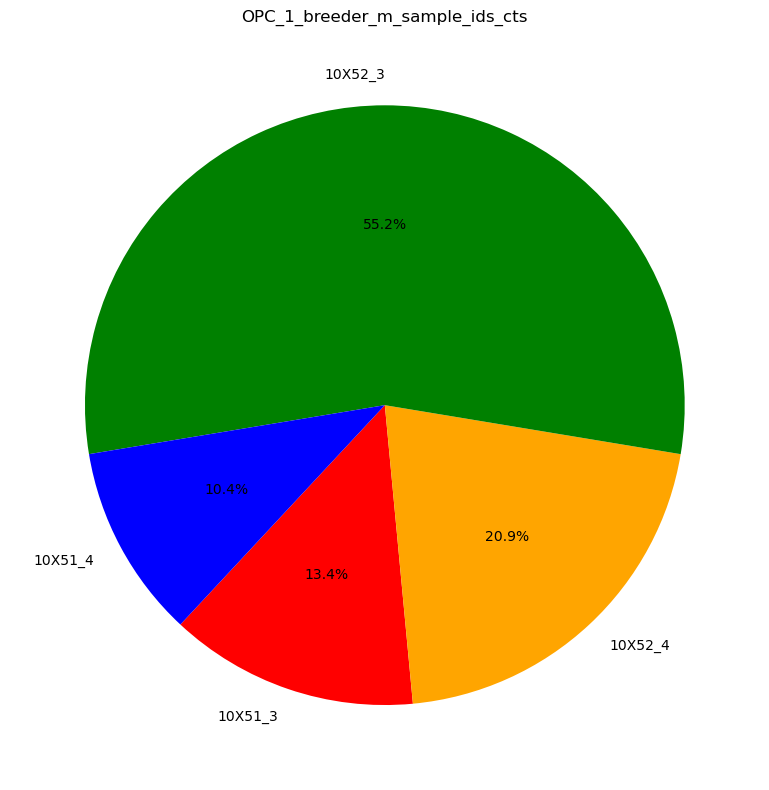

In [50]:
%matplotlib inline
# Extract labels and sizes
labels = list(OPC_1_breeder_m_sample_ids_cts.keys())
print (sorted(labels))
sizes = list(OPC_1_breeder_m_sample_ids_cts.values())

# Plot pie chart
plt.figure(figsize=(8, 8))

label_colors = {
    '10X51_3': 'red',
    '10X51_4': 'blue',
    '10X52_3': 'green',
    '10X52_4': 'orange'
}

# Define a reference label and its desired position (e.g., top center at 90 degrees)
reference_label = '10X52_3'
reference_angle = 90  # Desired angle for the reference label

# Calculate the startangle to align the reference label
reference_index = labels.index(reference_label)
cumulative_sizes = sum(sizes[:reference_index]) + sizes[reference_index] / 2
startangle = reference_angle - (cumulative_sizes / sum(sizes)) * 360


# Map the colors to the labels
colors = [label_colors[label] for label in labels]
#colors = plt.cm.tab20b(np.linspace(0, 1, len(sorted(labels))))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=startangle, colors=colors)
plt.title('OPC_1_breeder_m_sample_ids_cts')
plt.tight_layout()
plt.show()

In [60]:
sample_id = np.unique(NN_metadata_df.loc['SampleID'])
sample_id

array(['10X35_1', '10X35_2', '10X36_1', '10X36_2', '10X37_1', '10X37_2',
       '10X38_1', '10X38_2', '10X51_1', '10X51_2', '10X51_3', '10X51_4',
       '10X52_1', '10X52_2', '10X52_3', '10X52_4'], dtype=object)

In [61]:
#map sample ids to groups
sample_id_group_map = {'Breeder-F': ['10X51_2','10X51_1','10X52_1','10X52_2'],
                       'Breeder-M': ['10X51_3','10X51_4','10X52_3','10X52_4'],
                       'Naïve-F': [ '10X35_1', '10X35_2', '10X38_1', '10X38_2'],
                       'Naïve-M': ['10X36_1','10X36_2','10X37_1','10X37_2']
        }


In [66]:
[y for x in sample_id_group_map.values() for y in x]

['10X51_2',
 '10X51_1',
 '10X52_1',
 '10X52_2',
 '10X51_3',
 '10X51_4',
 '10X52_3',
 '10X52_4',
 '10X35_1',
 '10X35_2',
 '10X38_1',
 '10X38_2',
 '10X36_1',
 '10X36_2',
 '10X37_1',
 '10X37_2']

In [63]:
groups

array(['Breeder-F', 'Breeder-M', 'Naïve-F', 'Naïve-M'], dtype=object)

In [82]:
fn_list = np.unique(NN_metadata_df.loc['full_name'])
sample_list = [y for x in sample_id_group_map.values() for y in x]
sample_id_stats = pd.DataFrame(columns = sample_list)
full_names,idx = np.unique(NN_metadata_df.loc['full_name'],return_index=True)
sample_id_stats['full_name'] = full_names[np.argsort(idx)]
sample_id_stats = sample_id_stats.set_index('full_name')

In [83]:
full_names[np.argsort(idx)]

array(['Nonneuronal-1-Erythrocyte', 'Nonneuronal-2-Pericyte',
       'Nonneuronal-3-Endothelial', 'Nonneuronal-4-Microglia',
       'Nonneuronal-5-PVM', 'Nonneuronal-6-VSM',
       'Nonneuronal-7-Fibroblast', 'Nonneuronal-8-Proliferating_cells',
       'Nonneuronal-9-OPC_1', 'Nonneuronal-10-OPC_2',
       'Nonneuronal-11-Astro', 'Nonneuronal-12-Astro_gfap',
       'Nonneuronal-13-Epend', 'Nonneuronal-14-OL_1',
       'Nonneuronal-15-OL_2'], dtype=object)

In [84]:
sample_id_stats

,10X51_2,10X51_1,10X52_1,10X52_2,10X51_3,10X51_4,10X52_3,10X52_4,10X35_1,10X35_2,10X38_1,10X38_2,10X36_1,10X36_2,10X37_1,10X37_2
full_name,,,,,,,,,,,,,,,,
Nonneuronal-1-Erythrocyte,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nonneuronal-2-Pericyte,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nonneuronal-3-Endothelial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nonneuronal-4-Microglia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nonneuronal-5-PVM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nonneuronal-6-VSM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nonneuronal-7-Fibroblast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nonneuronal-8-Proliferating_cells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nonneuronal-9-OPC_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
sample_id_group_map

{'Breeder-F': ['10X51_2', '10X51_1', '10X52_1', '10X52_2'],
 'Breeder-M': ['10X51_3', '10X51_4', '10X52_3', '10X52_4'],
 'Naïve-F': ['10X35_1', '10X35_2', '10X38_1', '10X38_2'],
 'Naïve-M': ['10X36_1', '10X36_2', '10X37_1', '10X37_2']}

In [ ]:
for fn in fn_list:
    c_marker_subset = NN_metadata_df.loc[:,NN_metadata_df.loc['full_name']==fn]
    #total num cells in cluster
    num_cells = c_marker_subset.shape[1]
    for i,g in enumerate(groups):
        c_marker_subset_g = c_marker_subset.loc[:,c_marker_subset.loc['Group'] == g]
        num_cells_g = c_marker_subset_g.shape[1]
        #print (c_marker_subset_g.shape)
        for i,s in enumerate(sample_list):
            if s in sample_id_group_map[g]:
                perc_s = round((c_marker_subset_g.loc[:,c_marker_subset_g.loc['SampleID'] == sample_list[i]].shape[1]/num_cells_g)*100,2)    
                sample_id_stats.loc[fn,s] = perc_s
                #if fn == 'Nonneuronal-14-OL_1':
                    #print (fn,g,s,perc_s)


sample_id_stats

Nonneuronal-14-OL_1 Breeder-F 10X51_2 38.82
Nonneuronal-14-OL_1 Breeder-F 10X51_1 34.12
Nonneuronal-14-OL_1 Breeder-F 10X52_1 15.88
Nonneuronal-14-OL_1 Breeder-F 10X52_2 11.18
Nonneuronal-14-OL_1 Breeder-M 10X51_3 7.46
Nonneuronal-14-OL_1 Breeder-M 10X51_4 19.4
Nonneuronal-14-OL_1 Breeder-M 10X52_3 50.75
Nonneuronal-14-OL_1 Breeder-M 10X52_4 22.39
Nonneuronal-14-OL_1 Naïve-F 10X35_1 39.3
Nonneuronal-14-OL_1 Naïve-F 10X35_2 29.63
Nonneuronal-14-OL_1 Naïve-F 10X38_1 21.16
Nonneuronal-14-OL_1 Naïve-F 10X38_2 9.92
Nonneuronal-14-OL_1 Naïve-M 10X36_1 34.49
Nonneuronal-14-OL_1 Naïve-M 10X36_2 12.51
Nonneuronal-14-OL_1 Naïve-M 10X37_1 21.97
Nonneuronal-14-OL_1 Naïve-M 10X37_2 31.03


,10X51_2,10X51_1,10X52_1,10X52_2,10X51_3,10X51_4,10X52_3,10X52_4,10X35_1,10X35_2,10X38_1,10X38_2,10X36_1,10X36_2,10X37_1,10X37_2
full_name,,,,,,,,,,,,,,,,
Nonneuronal-1-Erythrocyte,33.33,66.67,0.0,0.0,16.67,83.33,0.0,0.0,0.0,0.0,38.89,61.11,22.22,0.0,55.56,22.22
Nonneuronal-2-Pericyte,21.81,24.5,23.83,29.87,21.9,24.79,30.17,23.14,26.78,30.6,28.96,13.66,19.49,16.1,34.75,29.66
Nonneuronal-3-Endothelial,19.6,32.0,19.6,28.8,20.56,23.33,31.11,25.0,40.0,28.8,16.8,14.4,21.28,16.31,31.91,30.5
Nonneuronal-4-Microglia,37.65,35.63,15.38,11.34,14.05,11.57,38.84,35.54,38.2,22.7,26.52,12.58,25.52,16.19,28.76,29.52
Nonneuronal-5-PVM,38.89,22.22,16.67,22.22,41.67,16.67,16.67,25.0,22.22,38.89,22.22,16.67,13.89,16.67,41.67,27.78
Nonneuronal-6-VSM,23.08,20.51,33.33,23.08,26.47,8.82,41.18,23.53,39.13,41.3,6.52,13.04,27.27,10.23,29.55,32.95
Nonneuronal-7-Fibroblast,40.0,10.0,30.0,20.0,7.69,30.77,15.38,46.15,26.32,42.11,26.32,5.26,8.33,33.33,25.0,33.33
Nonneuronal-8-Proliferating_cells,42.86,14.29,0.0,42.86,18.18,36.36,27.27,18.18,26.32,42.11,21.05,10.53,27.27,13.64,22.73,36.36
Nonneuronal-9-OPC_1,55.56,39.87,2.83,1.74,13.43,10.45,55.22,20.9,38.47,31.35,23.45,6.74,13.7,14.49,34.65,37.15


In [101]:
NN_cluster_sex_stats_df_percentage

,Breeder-F,Breeder-M,Naïve-F,Naïve-M
full_name,,,,
Nonneuronal-1-Erythrocyte,15.38,15.38,46.15,23.08
Nonneuronal-2-Pericyte,31.07,25.23,19.08,24.61
Nonneuronal-3-Endothelial,25.99,18.71,25.99,29.31
Nonneuronal-4-Microglia,18.46,9.04,33.26,39.24
Nonneuronal-5-PVM,21.43,14.29,21.43,42.86
Nonneuronal-6-VSM,18.84,16.43,22.22,42.51
Nonneuronal-7-Fibroblast,15.15,19.7,28.79,36.36
Nonneuronal-8-Proliferating_cells,11.86,18.64,32.2,37.29
Nonneuronal-9-OPC_1,22.31,3.26,37.53,36.9


In [91]:
NN_metadata_df

,GATCCCTCAATACGCT-1_10X38_2,TGATGGTCACAAGCCC-1_10X37_1,GGGTGAATCAAACGTC-1_10X38_1,TAACGACAGGATCACG-1_10X37_1,AGCGTATTCCGCAACG-1_10X38_2,GCAGGCTCACTCCTGT-1_10X38_2,ATGATCGGTCTGTCCT-1_10X38_2,TGATTCTAGTTTCGGT-1_10X38_1,AATAGAGGTTCATCGA-1_10X37_1,CATCGTCCAGTTACCA-1_10X51_2,...,GCACGTGGTTATTCCT-1_10X37_1,CAAGAGGGTCAATCTG-1_10X36_2,GGTGTCGAGAAGCTGC-1_10X36_2,AAGCCATGTGGATGAC-1_10X35_1,TTCTTCCCAAGACCTT-1_10X35_1,GAGAGGTCACATCATG-1_10X37_2,ATCAGGTTCCACTAGA-1_10X35_2,TCCACGTAGAGCATCG-1_10X37_1,CTGCGAGCACTACGGC-1_10X35_2,CTCTGGTTCGAAGCAG-1_10X37_1
Serial_Number,70.0,67.0,69.0,67.0,70.0,70.0,70.0,69.0,67.0,98.0,...,67.0,66.0,66.0,63.0,63.0,68.0,64.0,67.0,64.0,67.0
Date_Captured,2019-12-01,2019-11-25,2019-12-01,2019-11-25,2019-12-01,2019-12-01,2019-12-01,2019-12-01,2019-11-25,05/31/20,...,2019-11-25,2019-11-24,2019-11-24,2019-11-20,2019-11-20,2019-11-25,2019-11-20,2019-11-25,2019-11-20,2019-11-25
Species,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,...,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm
Transcriptome,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,...,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10
Strain,,,,,,,,,,C57Bl/6,...,,,,,,,,,,
Project,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,...,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph
Group,Naïve-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Naïve-F,Naïve-F,Naïve-F,Naïve-M,Breeder-F,...,Naïve-M,Naïve-M,Naïve-M,Naïve-F,Naïve-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Naïve-M
ChipID,10X38,10X37,10X38,10X37,10X38,10X38,10X38,10X38,10X37,10X51,...,10X37,10X36,10X36,10X35,10X35,10X37,10X35,10X37,10X35,10X37
SampleID,10X38_2,10X37_1,10X38_1,10X37_1,10X38_2,10X38_2,10X38_2,10X38_1,10X37_1,10X51_2,...,10X37_1,10X36_2,10X36_2,10X35_1,10X35_1,10X37_2,10X35_2,10X37_1,10X35_2,10X37_1
DonorID,DI6,"DI4,DI5",DI6,"DI4,DI5",DI6,DI6,DI6,DI6,"DI4,DI5",DI-B1-F,...,"DI4,DI5",DI3,DI3,"DI1,DI2","DI1,DI2","DI4,DI5","DI1,DI2","DI4,DI5","DI1,DI2","DI4,DI5"


In [123]:
groups

array(['Breeder-F', 'Breeder-M', 'Naïve-F', 'Naïve-M'], dtype=object)

/tmp/ipykernel_2194529/1676869324.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('nipy_spectral')  # Replace 'viridis' with your desired colormap


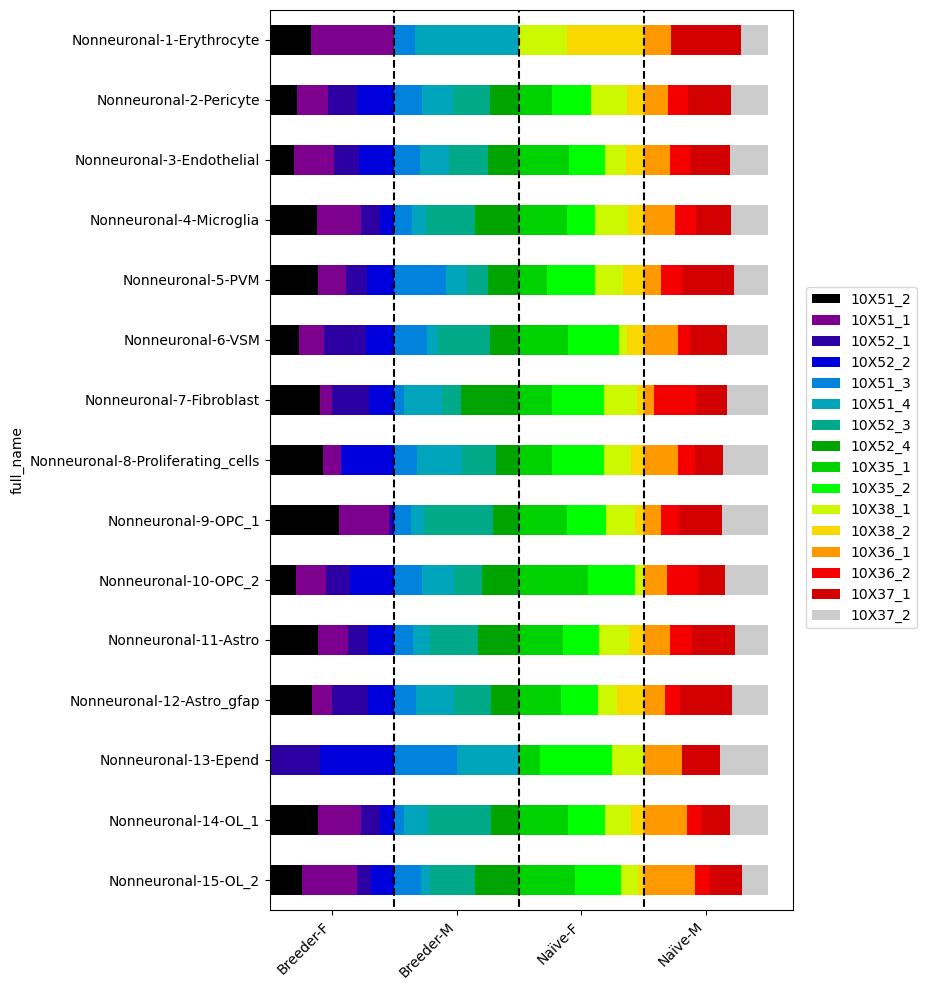

In [133]:
import matplotlib.cm as cm
# Generate colors from a colormap
cmap = cm.get_cmap('nipy_spectral')  # Replace 'viridis' with your desired colormap
colors = cmap(np.linspace(0, 1, len(sample_list)))

sample_id_stats.iloc[::-1].plot.barh(stacked=True, figsize=(10, 10), color=colors)
plt.xticks([50,150,250,350], [groups[0],groups[1],groups[2],groups[3]], rotation=45, ha='right')
plt.legend(sample_list, loc='upper right', bbox_to_anchor=(1.25, 0.7))
plt.tight_layout()
plt.vlines(x=(100, 200, 300), ymin=-1, ymax=sample_id_stats.shape[0], color='black', linestyle='--')
plt.savefig('/bigdata/isaac/Nonneuronal_files/sex_stats/NN_sample_id_stats_ro_prc.pdf')
plt.show()

In [135]:
groups

array(['Breeder-F', 'Breeder-M', 'Naïve-F', 'Naïve-M'], dtype=object)

In [134]:
NN_metadata_df

,GATCCCTCAATACGCT-1_10X38_2,TGATGGTCACAAGCCC-1_10X37_1,GGGTGAATCAAACGTC-1_10X38_1,TAACGACAGGATCACG-1_10X37_1,AGCGTATTCCGCAACG-1_10X38_2,GCAGGCTCACTCCTGT-1_10X38_2,ATGATCGGTCTGTCCT-1_10X38_2,TGATTCTAGTTTCGGT-1_10X38_1,AATAGAGGTTCATCGA-1_10X37_1,CATCGTCCAGTTACCA-1_10X51_2,...,GCACGTGGTTATTCCT-1_10X37_1,CAAGAGGGTCAATCTG-1_10X36_2,GGTGTCGAGAAGCTGC-1_10X36_2,AAGCCATGTGGATGAC-1_10X35_1,TTCTTCCCAAGACCTT-1_10X35_1,GAGAGGTCACATCATG-1_10X37_2,ATCAGGTTCCACTAGA-1_10X35_2,TCCACGTAGAGCATCG-1_10X37_1,CTGCGAGCACTACGGC-1_10X35_2,CTCTGGTTCGAAGCAG-1_10X37_1
Serial_Number,70.0,67.0,69.0,67.0,70.0,70.0,70.0,69.0,67.0,98.0,...,67.0,66.0,66.0,63.0,63.0,68.0,64.0,67.0,64.0,67.0
Date_Captured,2019-12-01,2019-11-25,2019-12-01,2019-11-25,2019-12-01,2019-12-01,2019-12-01,2019-12-01,2019-11-25,05/31/20,...,2019-11-25,2019-11-24,2019-11-24,2019-11-20,2019-11-20,2019-11-25,2019-11-20,2019-11-25,2019-11-20,2019-11-25
Species,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,...,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm
Transcriptome,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,...,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10
Strain,,,,,,,,,,C57Bl/6,...,,,,,,,,,,
Project,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,...,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph,Dimorph
Group,Naïve-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Naïve-F,Naïve-F,Naïve-F,Naïve-M,Breeder-F,...,Naïve-M,Naïve-M,Naïve-M,Naïve-F,Naïve-F,Naïve-M,Naïve-F,Naïve-M,Naïve-F,Naïve-M
ChipID,10X38,10X37,10X38,10X37,10X38,10X38,10X38,10X38,10X37,10X51,...,10X37,10X36,10X36,10X35,10X35,10X37,10X35,10X37,10X35,10X37
SampleID,10X38_2,10X37_1,10X38_1,10X37_1,10X38_2,10X38_2,10X38_2,10X38_1,10X37_1,10X51_2,...,10X37_1,10X36_2,10X36_2,10X35_1,10X35_1,10X37_2,10X35_2,10X37_1,10X35_2,10X37_1
DonorID,DI6,"DI4,DI5",DI6,"DI4,DI5",DI6,DI6,DI6,DI6,"DI4,DI5",DI-B1-F,...,"DI4,DI5",DI3,DI3,"DI1,DI2","DI1,DI2","DI4,DI5","DI1,DI2","DI4,DI5","DI1,DI2","DI4,DI5"


In [142]:
fn_list = pd.unique(NN_metadata_df.loc['full_name'])
fn_list 

array(['Nonneuronal-1-Erythrocyte', 'Nonneuronal-2-Pericyte',
       'Nonneuronal-3-Endothelial', 'Nonneuronal-4-Microglia',
       'Nonneuronal-5-PVM', 'Nonneuronal-6-VSM',
       'Nonneuronal-7-Fibroblast', 'Nonneuronal-8-Proliferating_cells',
       'Nonneuronal-9-OPC_1', 'Nonneuronal-10-OPC_2',
       'Nonneuronal-11-Astro', 'Nonneuronal-12-Astro_gfap',
       'Nonneuronal-13-Epend', 'Nonneuronal-14-OL_1',
       'Nonneuronal-15-OL_2'], dtype=object)

In [144]:

group_stats = pd.DataFrame(columns = fn_list)
full_names,idx = np.unique(NN_metadata_df.loc['full_name'],return_index=True)
group_stats['groups'] = groups
group_stats = group_stats.set_index('groups')

In [145]:
group_stats

,Nonneuronal-1-Erythrocyte,Nonneuronal-2-Pericyte,Nonneuronal-3-Endothelial,Nonneuronal-4-Microglia,Nonneuronal-5-PVM,Nonneuronal-6-VSM,Nonneuronal-7-Fibroblast,Nonneuronal-8-Proliferating_cells,Nonneuronal-9-OPC_1,Nonneuronal-10-OPC_2,Nonneuronal-11-Astro,Nonneuronal-12-Astro_gfap,Nonneuronal-13-Epend,Nonneuronal-14-OL_1,Nonneuronal-15-OL_2
groups,,,,,,,,,,,,,,,
Breeder-F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Breeder-M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Naïve-F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Naïve-M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [148]:
for g in groups:
    g_subset = NN_metadata_df.loc[:,NN_metadata_df.loc['Group']==g]
    #total num cells in cluster
    num_cells = g_subset.shape[1]
    for i,fn in enumerate(fn_list):
        g_subset_fn = g_subset.loc[:,g_subset.loc['full_name'] == fn]
        num_cells_fn = g_subset_fn.shape[1]
        perc_s = round((g_subset_fn.shape[1]/num_cells)*100,2)  
        group_stats.loc[g,fn] = perc_s



group_stats

,Nonneuronal-1-Erythrocyte,Nonneuronal-2-Pericyte,Nonneuronal-3-Endothelial,Nonneuronal-4-Microglia,Nonneuronal-5-PVM,Nonneuronal-6-VSM,Nonneuronal-7-Fibroblast,Nonneuronal-8-Proliferating_cells,Nonneuronal-9-OPC_1,Nonneuronal-10-OPC_2,Nonneuronal-11-Astro,Nonneuronal-12-Astro_gfap,Nonneuronal-13-Epend,Nonneuronal-14-OL_1,Nonneuronal-15-OL_2
groups,,,,,,,,,,,,,,,
Breeder-F,0.22,10.85,9.1,8.99,0.66,1.42,0.36,0.25,16.71,1.53,34.98,1.38,0.18,12.38,0.98
Breeder-M,0.38,15.51,11.54,7.76,0.77,2.18,0.83,0.71,4.29,1.73,42.12,2.56,0.13,8.59,0.9
Naïve-F,0.46,4.69,6.41,11.4,0.46,1.18,0.49,0.49,19.78,1.15,28.09,1.54,0.31,21.19,2.36
Naïve-M,0.21,5.63,6.73,12.53,0.86,2.1,0.57,0.53,18.12,0.76,23.97,1.38,0.31,23.47,2.82


In [149]:
group_stats.sum(axis=1)

groups
Breeder-F    99.99
Breeder-M    100.0
Naïve-F      100.0
Naïve-M      99.99
dtype: object

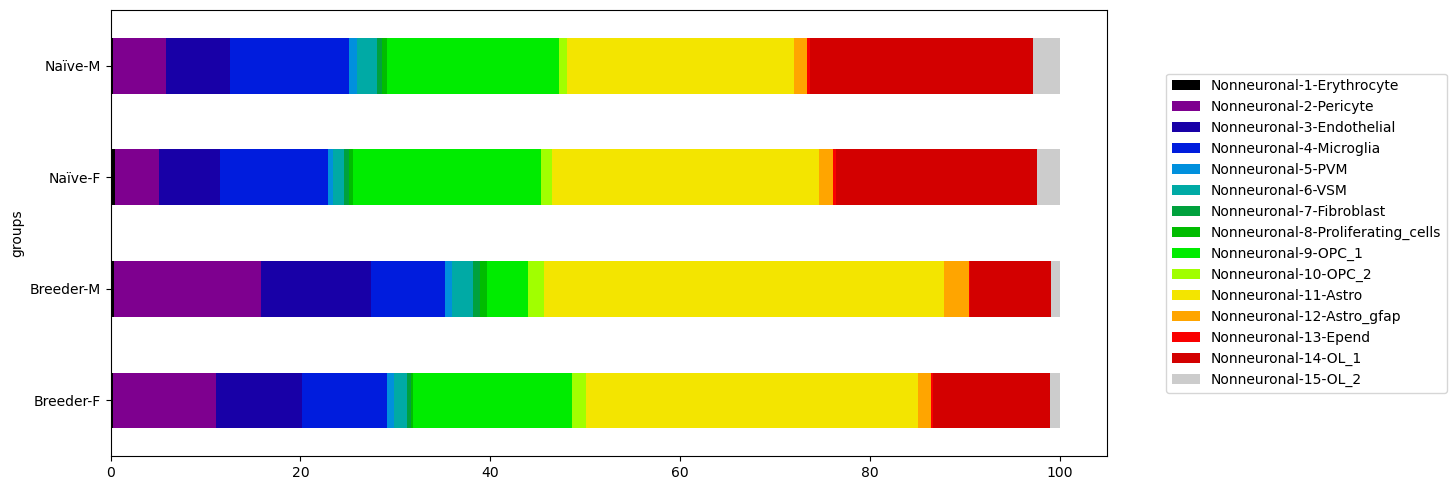

In [170]:
# Generate colors from a colormap
cmap = mpl.colormaps.get_cmap('nipy_spectral')  # Replace 'viridis' with your desired colormap
colors = cmap(np.linspace(0, 1, len(fn_list)))

group_stats.plot.barh(stacked=True, figsize=(15, 5), color=colors)
#plt.xticks([50,150,250,350], [groups[0],groups[1],groups[2],groups[3]], rotation=45, ha='right')
plt.legend(fn_list, loc='center', bbox_to_anchor=(1.2, 0.5))
plt.tight_layout()
#plt.vlines(x=(100, 200, 300), ymin=-1, ymax=sample_id_stats.shape[0], color='black', linestyle='--')
plt.savefig('/bigdata/isaac/Nonneuronal_files/sex_stats/NN_sample_group_stats_prc.pdf')
plt.show()

In [155]:
NN_cluster_sex_stats_df

,Breeder-F,Breeder-M,Naïve-F,Naïve-M,num_cells,num_sample_ids,sample_ids
full_name,,,,,,,
Nonneuronal-1-Erythrocyte,6,6,18,9,39,9,"['10X36_1', '10X37_1', '10X37_2', '10X38_1', '..."
Nonneuronal-2-Pericyte,298,242,183,236,959,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-3-Endothelial,250,180,250,282,962,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-4-Microglia,247,121,445,525,1338,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-5-PVM,18,12,18,36,84,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-6-VSM,39,34,46,88,207,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-7-Fibroblast,10,13,19,24,66,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-8-Proliferating_cells,7,11,19,22,59,15,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
Nonneuronal-9-OPC_1,459,67,772,759,2057,16,"['10X35_1', '10X35_2', '10X36_1', '10X36_2', '..."
